# Purpose of the Code

The goal of this notebook is to extract EMG and IMU signals recorded using Myo armband and Trigno Avanti sensors, process the raw data, extract meaningful features, and store the resulting information in a structured DataFrame format.

## Environment Setup

In [1]:
# pip install libemg  # Required only if you have never installed the libemg package
# pip install --upgrade paramiko cryptography  # Needed during first-time installation of libemg to resolve dependencies

In [2]:
import os
import pandas as pd
import numpy as np
import sys
sys.path.append('../lib')
from import_file import import_data_from_myo, import_data_from_trigno
from myo_utils import myo_dataframe_edit, myo_extract_muscle_emg, myo_extract_imu
from trigno_utils import trigno_dataframe_edit, trigno_extract_muscle_emg, trigno_extract_muscle_IMU
from emg_utils import plot_emg_signal, emg_filters, extract_emg_windows_v2, extract_emg_features, normalize_emg_data, align_and_get_bkps_trigno
from imu_utils import (plot_imu_signals, detect_segments_imu, process_imu_segments, extract_imu_windows, extract_imu_features, compute_vm_features, 
                        align_imu_signals_trigno, plot_imu_myo, plot_imu_segmented_myo, detect_segments_imu_myo, process_imu_myo, 
                        extract_imu_windows_myo, extract_imu_features_myo, compute_vm_features_myo)
from features_utils import combine_multiple_features_lists, detect_segments_v2, assign_emg_labels_v2, compute_offset_trigno_myo

In [183]:
# Subject and Acquisition Info
subj = "07" # Subject ID
date = "_test" # Date or tag for the acquisition
folder = "Seq1" # Sequence name (used to determine intensity order)

# Intensity Parameters
intensity_map = {"Seq1": ["medium", "light", "heavy"],
                "Seq2": ["medium", "heavy", "light"],
                "Seq3": ["heavy", "medium", "light"]}
intensity_level = intensity_map.get(folder, [])  # Intensity order for the selected sequence

# Myo Armband Settings
fs_myo = 200 # Sampling frequency of Myo armband [Hz]
channel_numbers = [1, 2, 3, 4, 5, 6, 7, 8]   # Available Myo EMG channels
channel_ref_number = 5 # Channel used as reference for labeling
channel_names = [f"channel_{num}" for num in channel_numbers] # Channel name list
channel_ref = f"channel_{channel_ref_number}" # Reference channel name

# Trigno System Settings
muscle_names = ["biceps", "triceps"]  # Trigno muscles of interest
muscle_ref = "biceps" # Muscle used as reference for labeling
axes = ["X", "Y", "Z"] # Trigno IMU axes
cutoff_imu = 5 # Frequency for low-pass IMU filter
lenght = 28 # Number of relevant columns in Trigno CSV

# Task and Windowing Parameters
n_lifts = 5  # Number of lifting actions per segment
n_segments = 3  # Number of intensity segments
w_d = 0.2  # Window duration for features [s]
ov = 0.5   # Window overlap ratio
step = w_d * ov # Step size between windows [s]
duration = 70 # Duration of each segment [s]
rest = 60 # Rest time between segments [s]

# Time Windows for Segmentation
windows_s = [(i * (duration + rest), i * (duration + rest) + duration) for i in range(n_segments)]  # Time segments for Myo
windows_trigno = [(i * (duration + rest) + 5, i * (duration + rest) + duration +5) for i in range(n_segments)] # Time segments for Trigno (5s shifted)
windows_per_segment = int(np.ceil((duration - w_d) / step)) # Number of windows per segment

# Signal Normalization Parameters
smooth_threshold_trigno = 0.005 # Max smoothness allowed for Trigno signal normalization
smooth_threshold_myo = 3 # Max smoothness allowed for Myo signal normalization
time_factor = 2  # Window size for max value extraction during normalization [s]

# Index lists for windowed data
windows_idx_emg_list_myo = []  # Window indices for Myo EMG
windows_idx_emg_list_trigno = []  # Window indices for Trigno EMG
windows_idx_imu_list_myo = []  # Window indices for Myo IMU
windows_idx_imu_list_trigno = []  # Window indices for Trigno IMU

# Sampling frequency lists
fs_emg_list_myo = []  # Sampling frequencies for Myo EMG
fs_imu_list_myo = []  # Sampling frequencies for Myo IMU
fs_emg_list_trigno = []  # Sampling frequencies for Trigno EMG
fs_imu_list_trigno = []  # Sampling frequencies for Trigno IMU

# Feature lists
features_list_norm = ['MAV', 'WL', 'VAR', 'LD', 'SAMPEN', 'MPK', 'WAMP']  # Features on normalized EMG signals
features_list_filt = ['ZC', 'SSC', 'KURT', 'SKEW']  # Features on filtered EMG signals
features_list_freq = ['MNF', 'MNP', 'SM', 'ISD']  # Frequency-domain EMG features
features_list_imu = ['MAV', 'WL', 'VAR', 'WAMP', 'ZC', 'SKEW', 'MNF', 'MNP']  # Features extracted from IMU signals

# Paths for input and output
input_folder_myo = f'../data/acquisitions/myo/{date}/S{subj}/{folder}/'  # Input path for Myo raw data
input_folder_trigno = f'../data/acquisitions/trigno/{date}/S{subj}/{folder}/'  # Input path for Trigno raw data
output_folder = f'../data/extracted_features/{date}/S{subj}/'  # Output path for saving feature datasets
output_filename = f"S{subj}_{folder}_features.csv"  # Filename for final features CSV

# Paths for MVC data
mvc = f'../data/mvc_values/{date}/mvc.csv'  # Path to Myo MVC values

# Loading Data Files

MYO

In [184]:
dataframes_myo = import_data_from_myo(input_folder_myo)  # Import raw data from Myo folder
dataframes_myo = [myo_dataframe_edit(df) for df in dataframes_myo]  # Format each imported dataframe

In [185]:
muscle_emg_raw_myo, emg_time_myo = myo_extract_muscle_emg(dataframes_myo, channel_names, fs_myo)  # Extract EMG signals for the specified channels

In [186]:
#for i in range(len(emg_time_myo)):
#    emg_signal = muscle_emg_raw_myo[channel_ref][i]
#    time_vector = emg_time_myo[i]
#    plot_emg_signal(emg_signal, time_vector, title=f"Myo {channel_ref} EMG Raw Signal #{i+1}", ylabel="bit") # Plot raw EMG signals from Myo 

In [187]:
imu_myo, imu_time_myo, fs_imu_list_myo = myo_extract_imu(dataframes_myo)  # Extract IMU data, time vectors, and sampling rate from Myo data

In [188]:
#plot_imu_myo(muscle_imu_myo, imu_time_myo)  # Plot raw IMU signals from Myo 

TRIGNO

In [189]:
dataframes_trigno = import_data_from_trigno(input_folder_trigno, lenght)  # Import raw data from Trigno folder
dataframes_trigno = [trigno_dataframe_edit(df) for df in dataframes_trigno]  # Format each imported dataframe

In [190]:
muscle_emg_raw_trigno, emg_time_trigno = trigno_extract_muscle_emg(dataframes_trigno, muscle_names)  # Extract EMG signals for the specified muscles

In [191]:
#for i in range(len(emg_time_trigno)):
#    emg_signal = muscle_emg_raw_trigno[muscle_ref][i]
#    time_vector = emg_time_trigno[i]
#    plot_emg_signal(emg_signal, time_vector, title=f"Trigno {muscle_ref} EMG Raw Signal #{i+1}")  # Plot raw EMG signals from Trigno

In [192]:
muscle_imu_trigno, imu_time_trigno = trigno_extract_muscle_IMU(dataframes_trigno, muscle_names) # Extract IMU data and time vectors from Trigno data

In [193]:
#plot_imu_signals(muscle_imu_trigno, imu_time_trigno, muscle_names, axes, flag=True) # Plot raw IMU signals from Trigno

# EMG Signal Analysis

## Filtering, Rectification, Smoothing, Normalization

MYO

In [194]:
for time in emg_time_myo:
    windows_idx = [(int(fs_myo * start), int(fs_myo * end)) for start, end in windows_s]  # Convert time windows to sample indices
    windows_idx_emg_list_myo.append(windows_idx)  # Store window indices per Myo EMG trial
    fs_emg_list_myo.append(fs_myo)  # Store Myo EMG sampling frequency per trial
fs_emg_list_ext_myo = [fs for fs in fs_emg_list_myo for _ in range(n_segments)]  # Extend sampling freq list for each segment in each trial

In [195]:
# Apply filters to raw Myo EMG signals
muscle_emg_filtered_myo, _, _, muscle_emg_normalized_myo = emg_filters(muscle_emg_raw_myo, emg_time_myo, fs_emg_list_myo, channel_names, mvc, subj) 

In [196]:
#for i in range(len(emg_time_myo)):
#    for channel in channel_names:
#        emg_signal = muscle_emg_normalized_myo[channel][i]
#        time_vector = emg_time_myo[i]
#        plot_emg_signal(emg_signal, time_vector, title=f"Myo {channel} EMG Normalized Signal #{i+1}", ylabel="bit") # Plot smoothed EMG signals from Myo 

TRIGNO

In [197]:
for time in emg_time_trigno:
    fs = 1.0 / np.mean(np.diff(time))  # Calculate sampling frequency from time intervals
    windows_idx = [(int(fs * start), int(fs * end)) for start, end in windows_s] # Convert time windows to sample indices
    windows_idx_emg_list_trigno.append(windows_idx) # Store window indices per Trigno EMG trial
    fs_emg_list_trigno.append(fs)  # Store Trigno EMG sampling frequency per trial

In [198]:
# Apply filters to raw Trigno EMG signals
muscle_emg_filtered_trigno, _, _, muscle_emg_normalized_trigno= emg_filters(muscle_emg_raw_trigno, 
                                                                             emg_time_trigno, fs_emg_list_trigno, muscle_names, mvc, subj) 

In [199]:
#for i in range(len(emg_time_trigno)):
#    for muscle in muscle_names:
#        emg_signal = muscle_emg_normalized_trigno[muscle][i]
#        time_vector = emg_time_trigno[i]
#        plot_emg_signal(emg_signal, time_vector, title=f"Trigno {muscle} EMG Normalized Signal #{i+1}") # Plot smoothed EMG signals from Trigno

## Labeling and Synchronization

MYO LABELING 

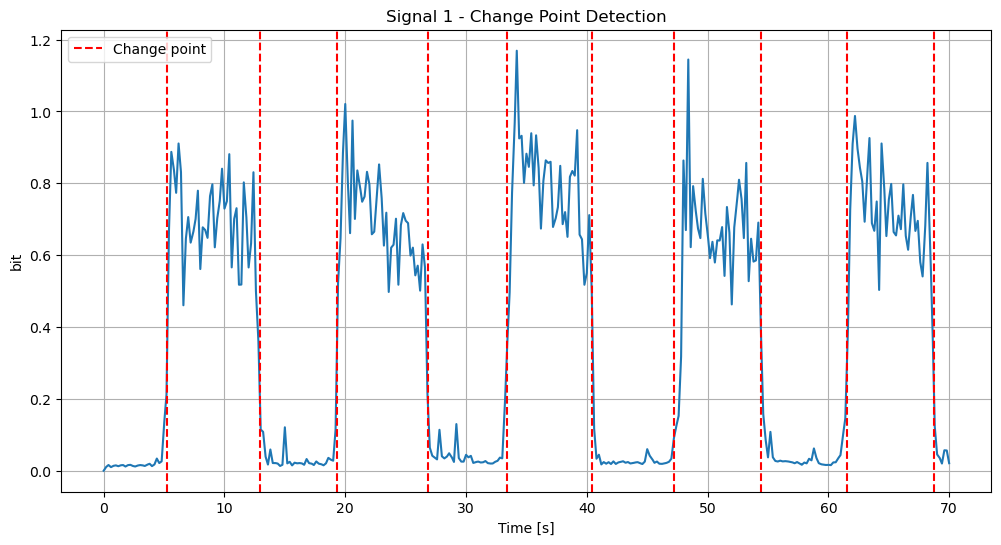

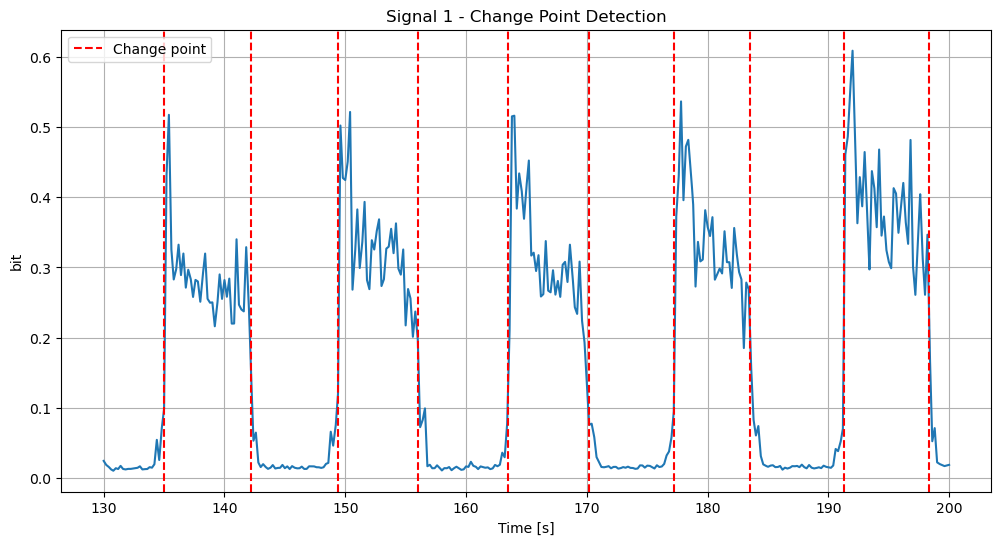

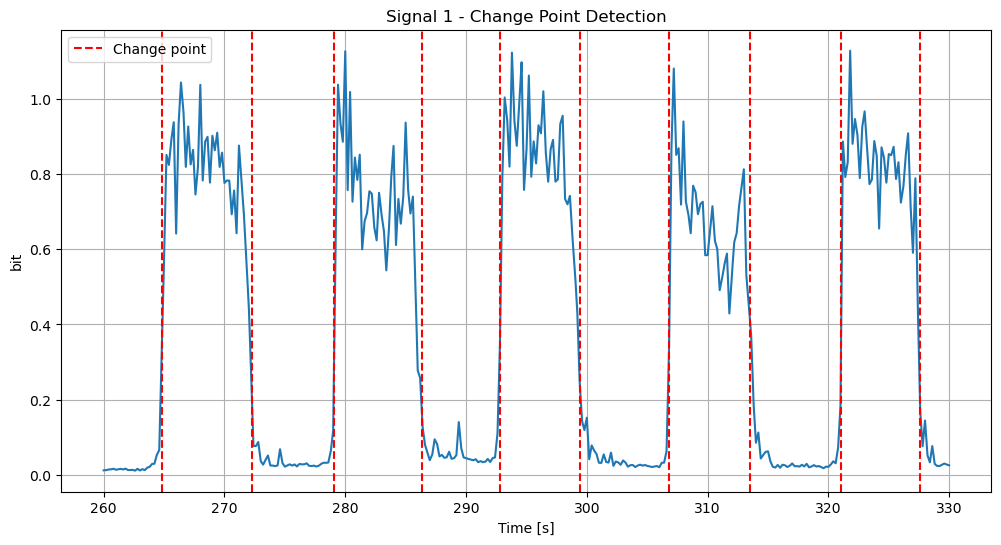

In [200]:
# Detect segments and breakpoints in Myo EMG data using smoothed and filtered signals based on defined windows and intensities
emg_norm_cut_myo, emg_filt_cut_myo, emg_time_cut_myo, breakpoints_myo = detect_segments_v2(emg_time_myo, muscle_emg_normalized_myo, 
    muscle_emg_filtered_myo, channel_names, channel_ref, windows_idx_emg_list_myo, intensity_level, n_lifts, fs_emg_list_myo, flag=True)

SYNCHRONIZATION

In [201]:
# Compute time offset between Trigno and Myo EMG signals to synchronize segments based on detected breakpoints
diff = compute_offset_trigno_myo(emg_time_trigno, emg_time_myo, fs_emg_list_trigno, windows_trigno, intensity_level,
    muscle_emg_normalized_trigno, muscle_ref, breakpoints_myo, n_lifts)


Offset #1 Trigno - Myo: 2.6461 s


In [202]:
# Align Trigno EMG signals with Myo using computed offset and retrieve updated breakpoints for Trigno data
(emg_time_trigno, muscle_emg_normalized_trigno, 
muscle_emg_filtered_trigno, breakpoints_trigno) = align_and_get_bkps_trigno(emg_time_trigno, emg_time_myo, muscle_emg_normalized_trigno,
                                                                           muscle_emg_filtered_trigno, breakpoints_myo, muscle_names, diff)

In [203]:
# Align Trigno IMU signals in time using the calculated offset to synchronize with Myo data
imu_time_trigno, muscle_imu_trigno = align_imu_signals_trigno(imu_time_trigno, muscle_imu_trigno, muscle_names, axes, diff)

In [204]:
# Detect and segment EMG signals from Trigno device using smoothed and filtered data
emg_norm_cut_trigno, emg_filt_cut_trigno, emg_time_cut_trigno, _ = detect_segments_v2(emg_time_trigno, muscle_emg_normalized_trigno, 
    muscle_emg_filtered_trigno, muscle_names, muscle_ref, windows_idx_emg_list_trigno, intensity_level, n_lifts, fs_emg_list_trigno, flag=False)

MYO PLOT

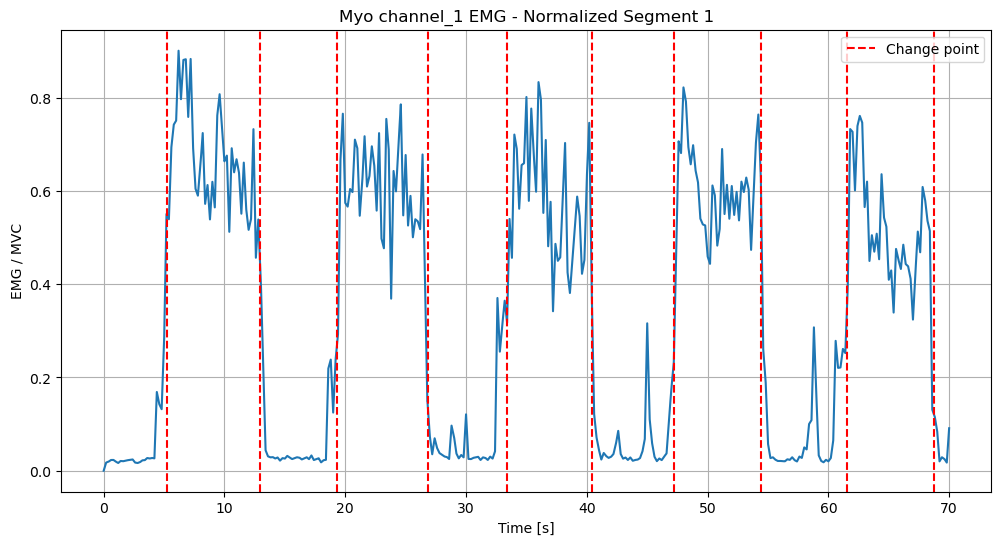

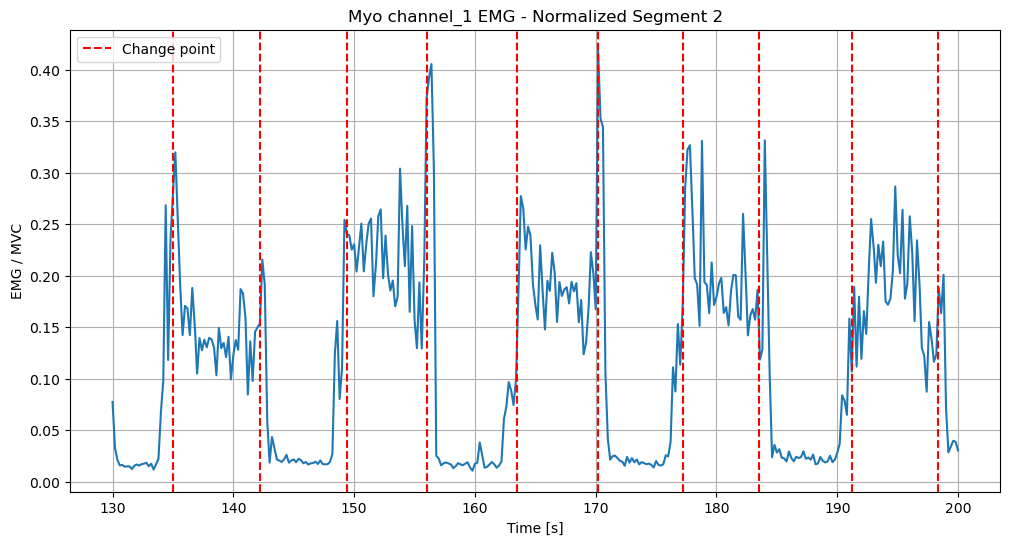

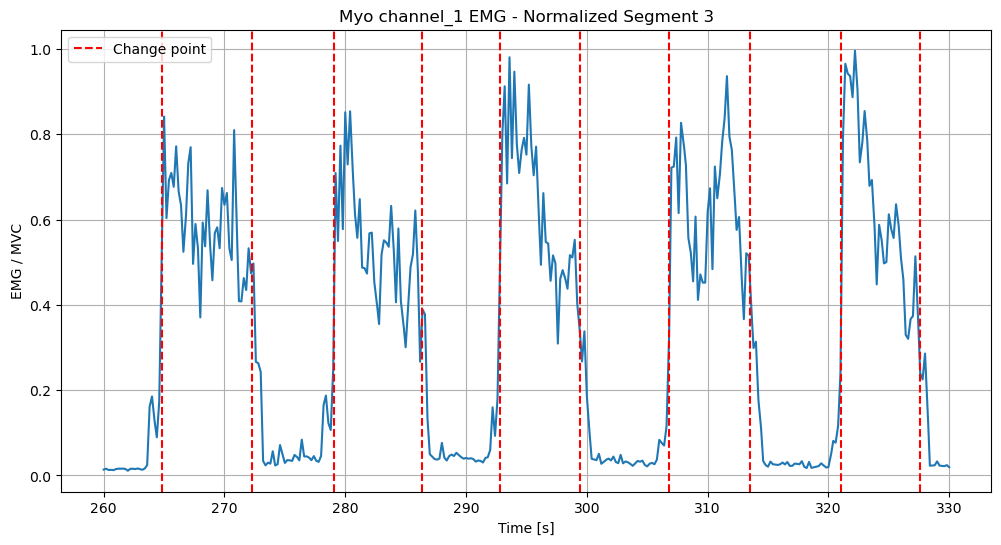

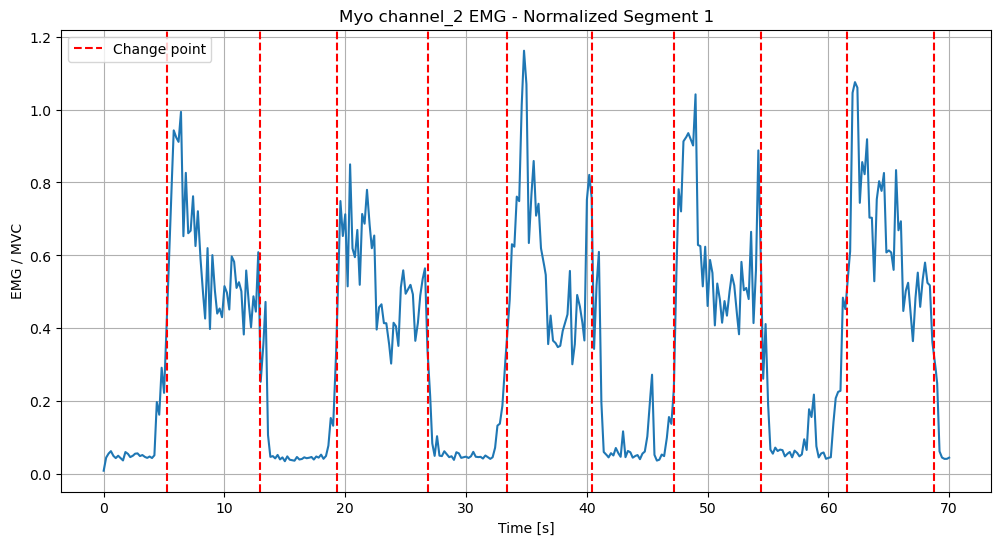

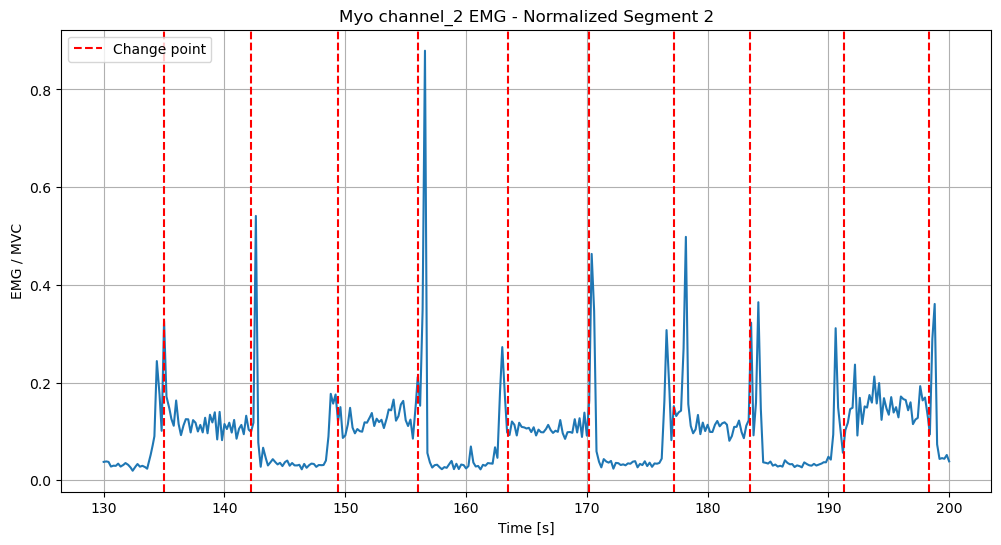

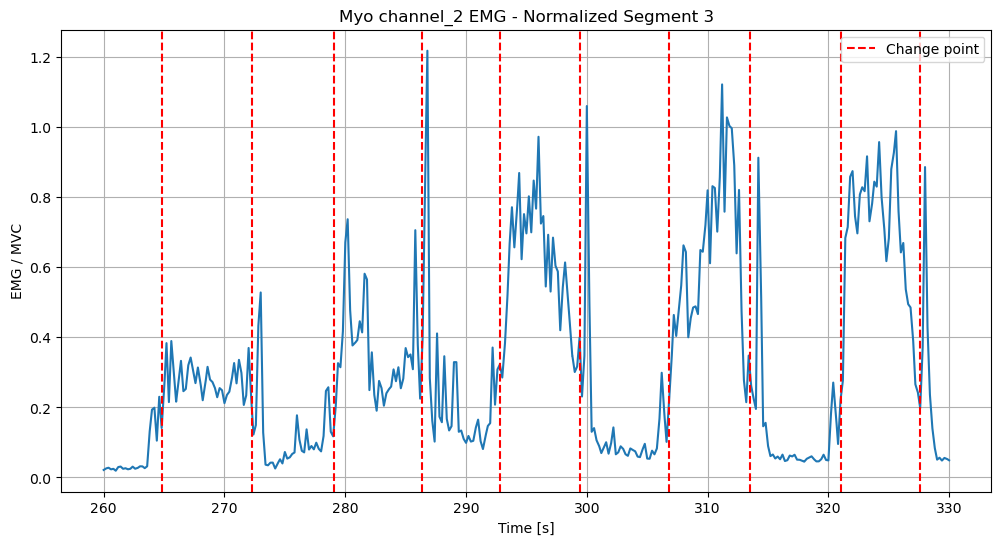

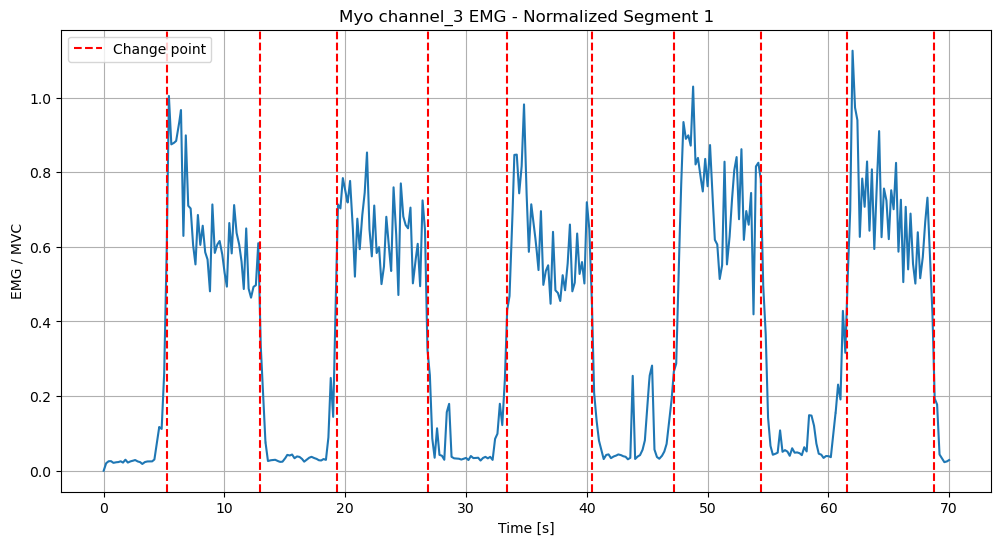

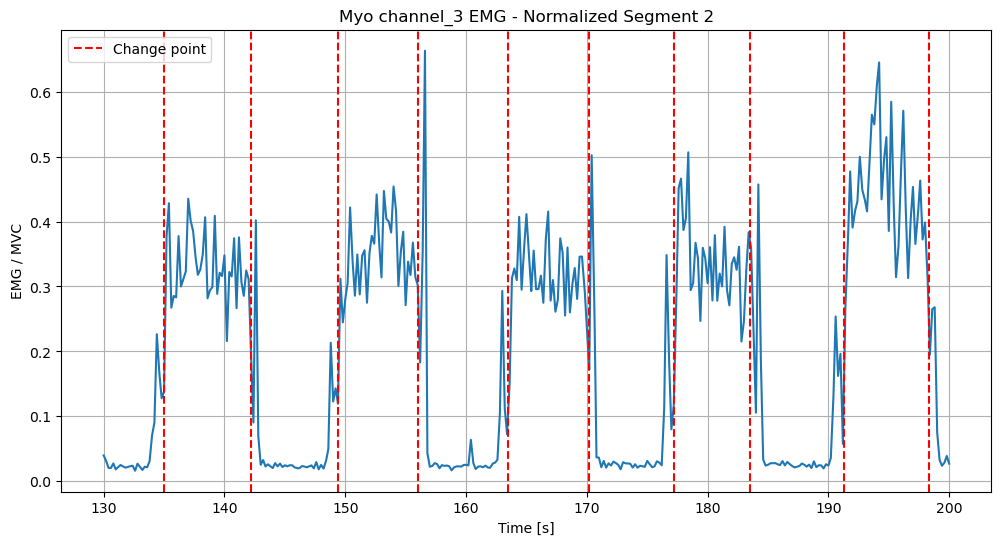

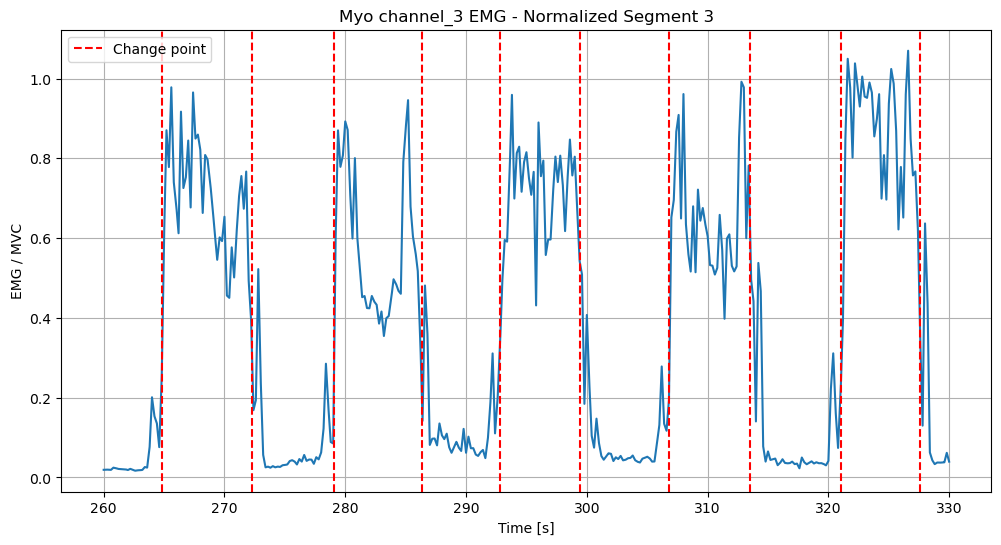

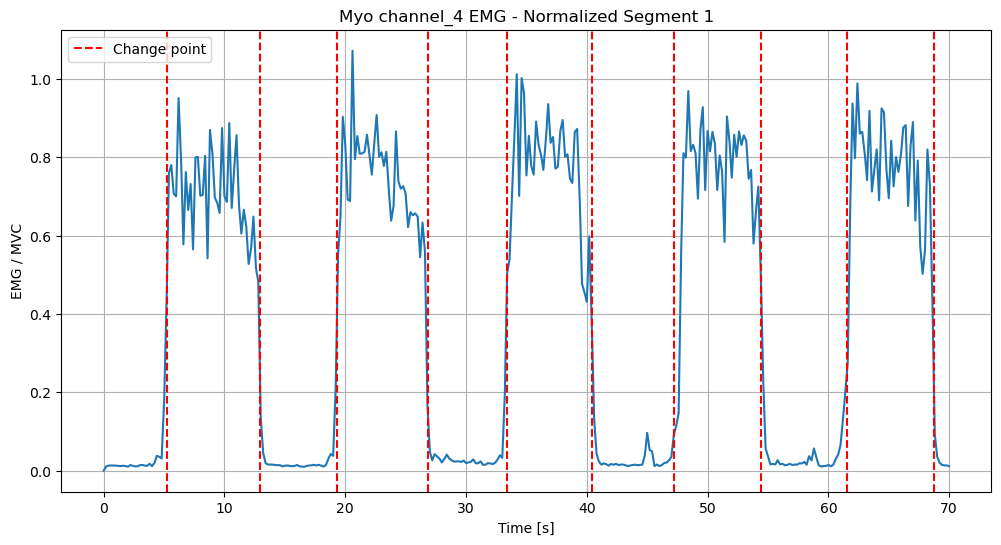

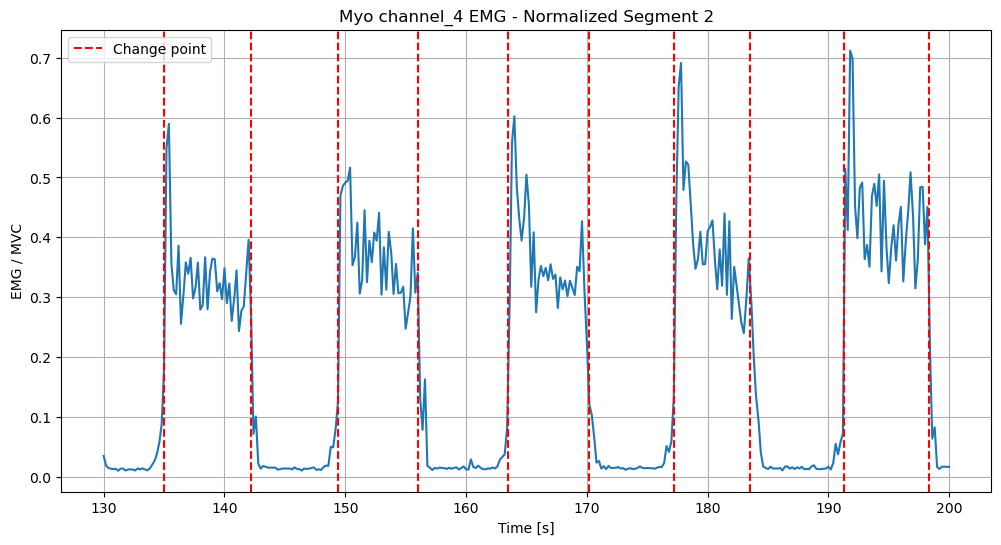

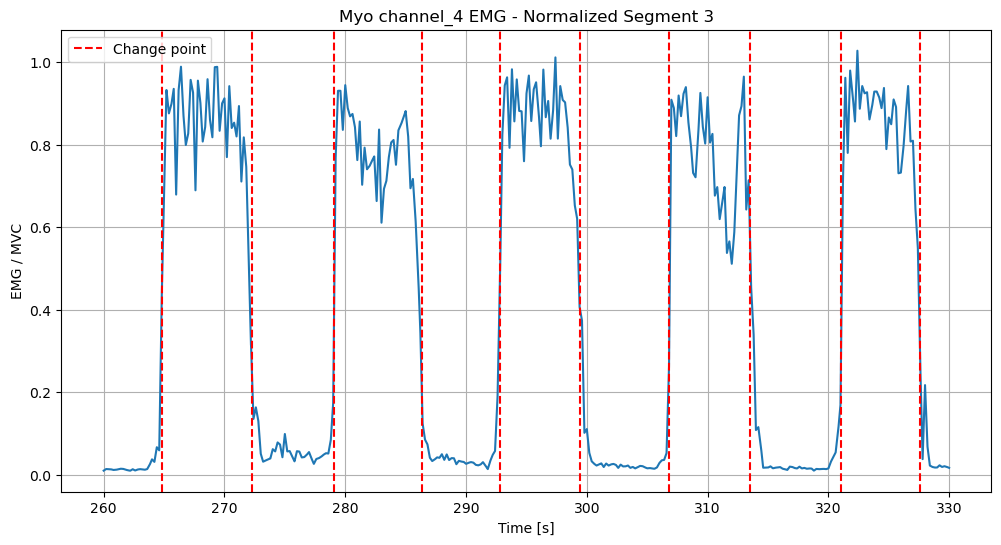

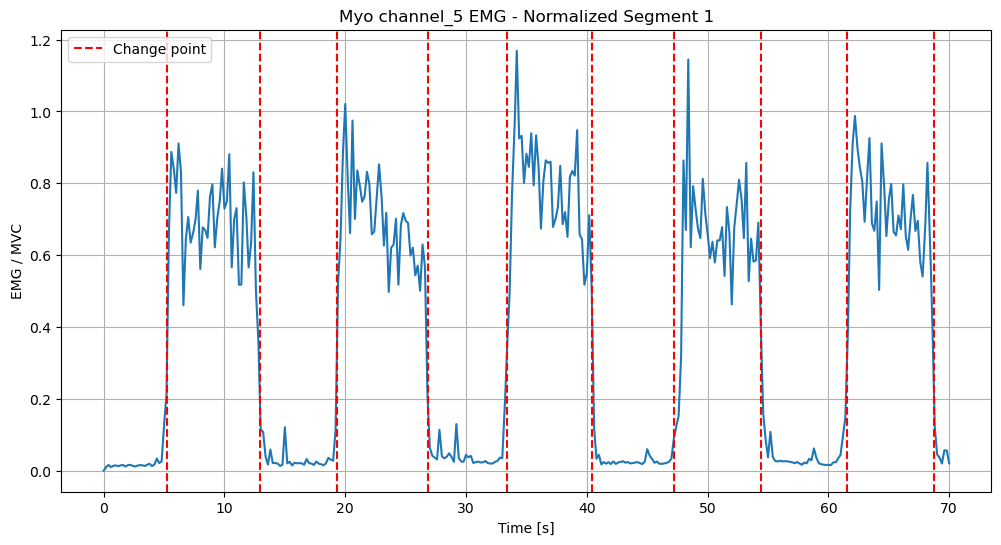

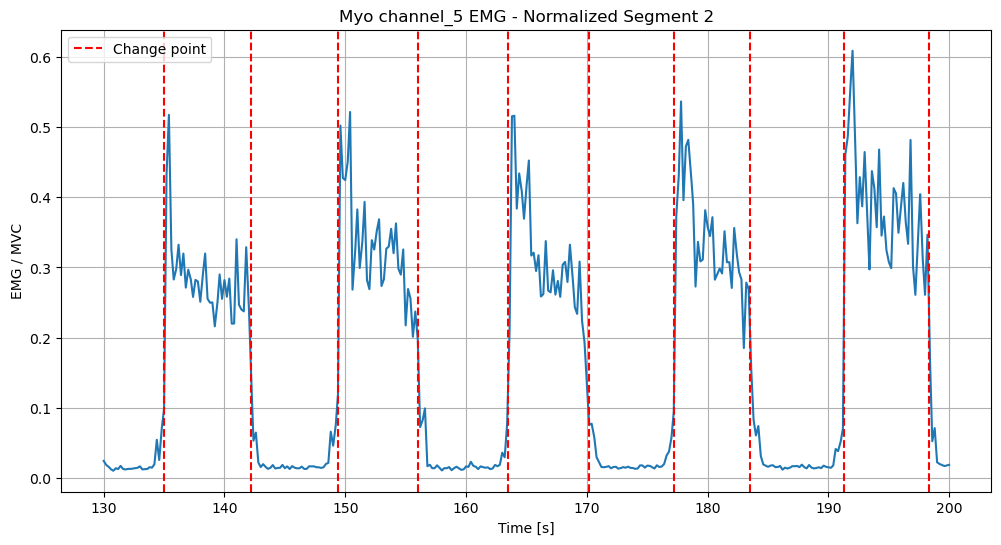

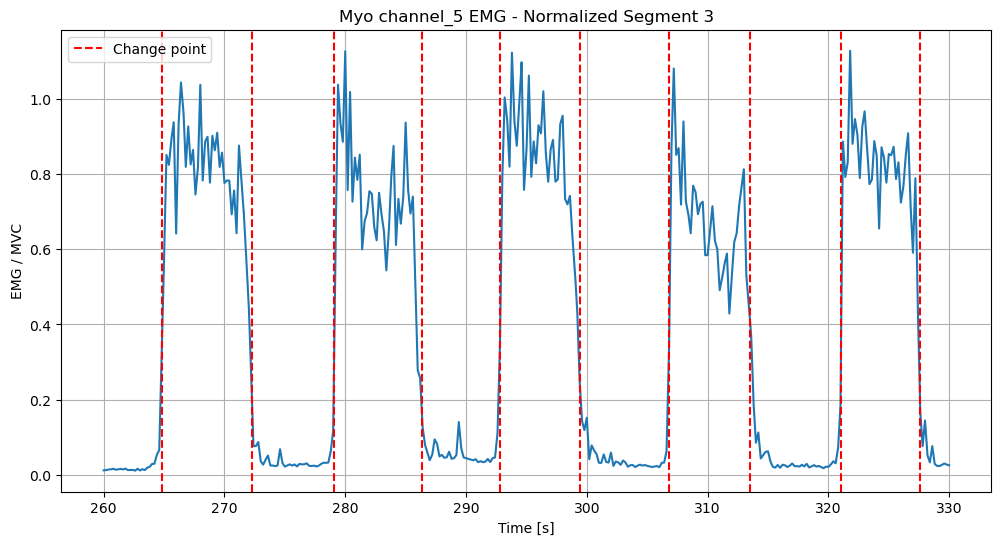

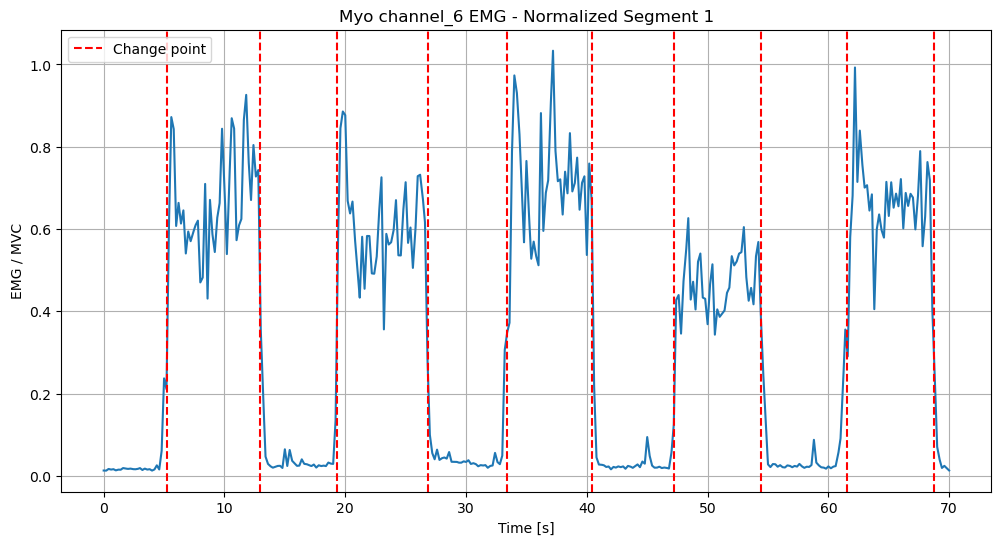

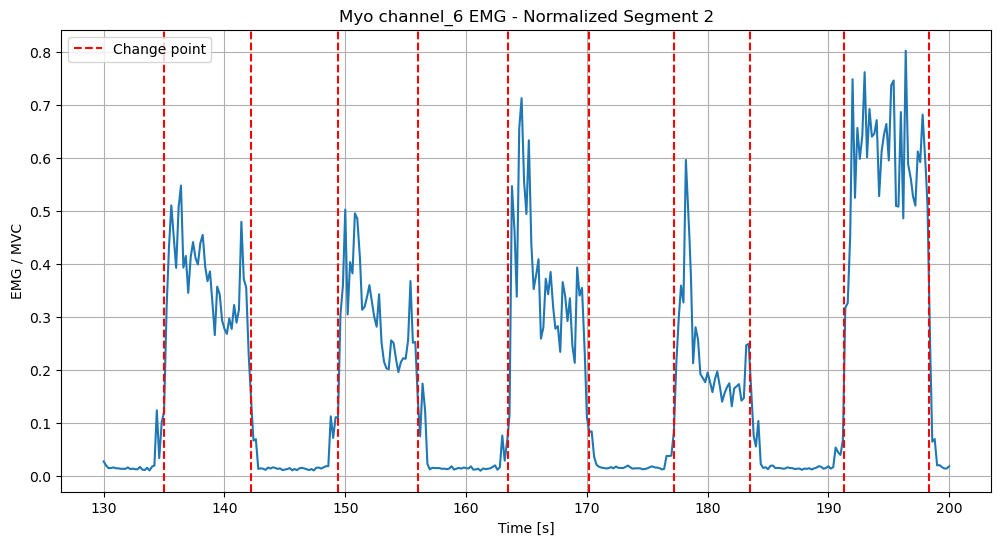

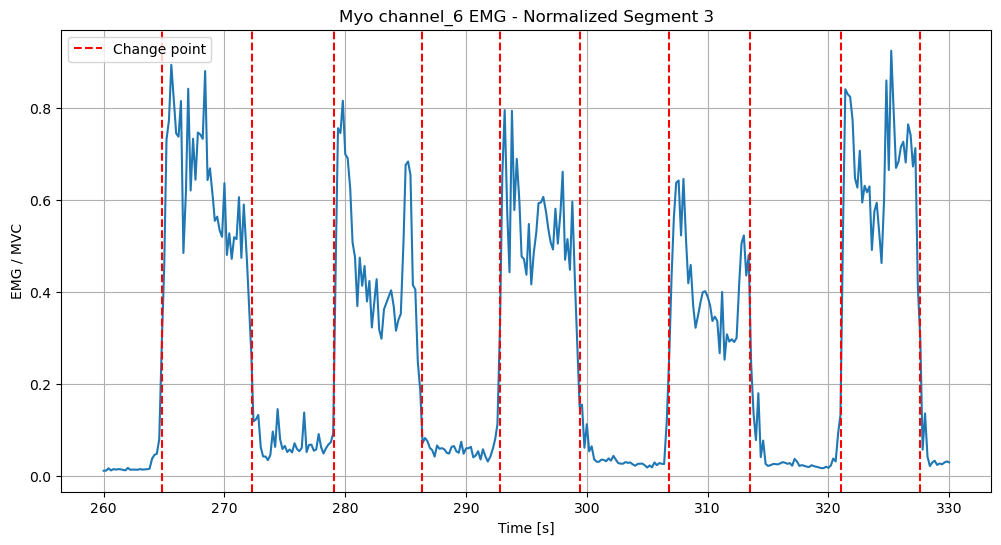

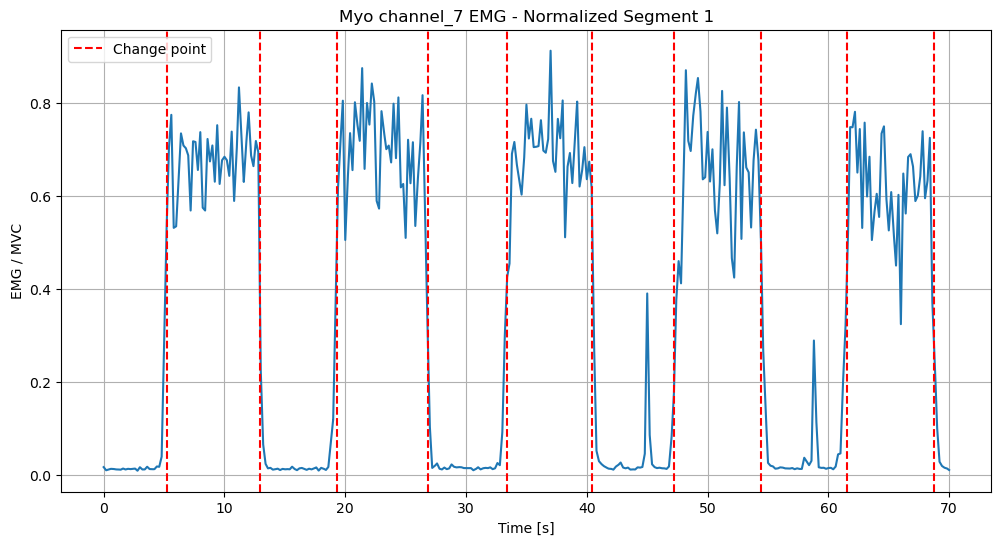

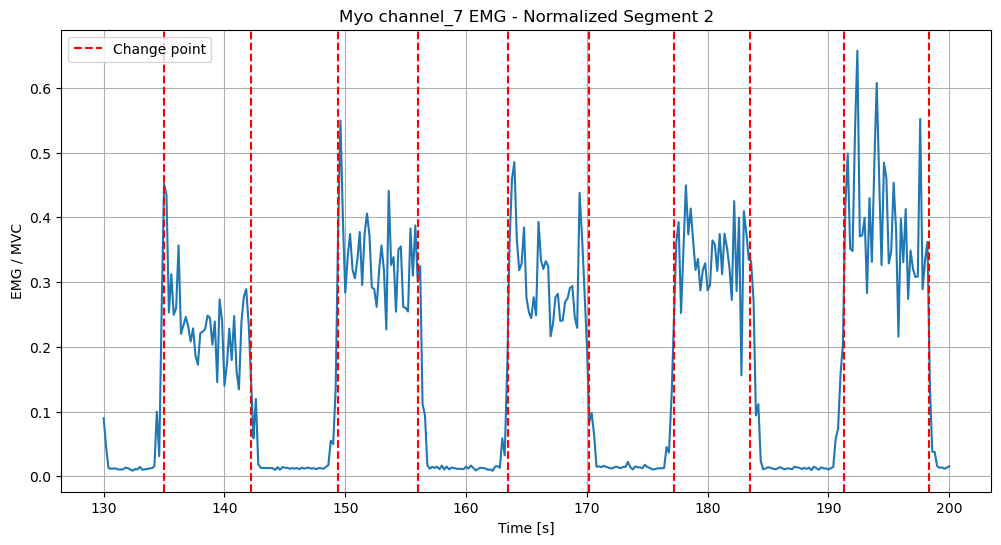

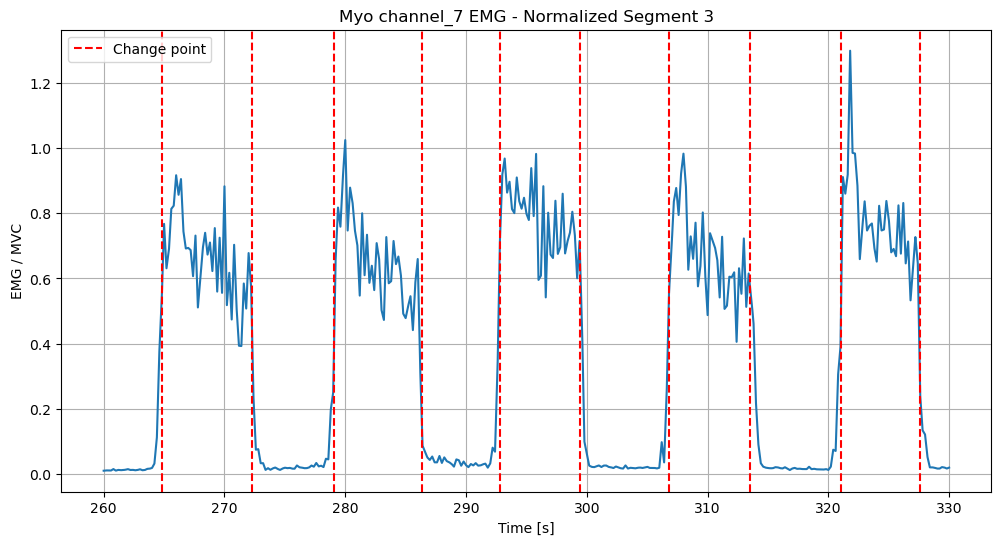

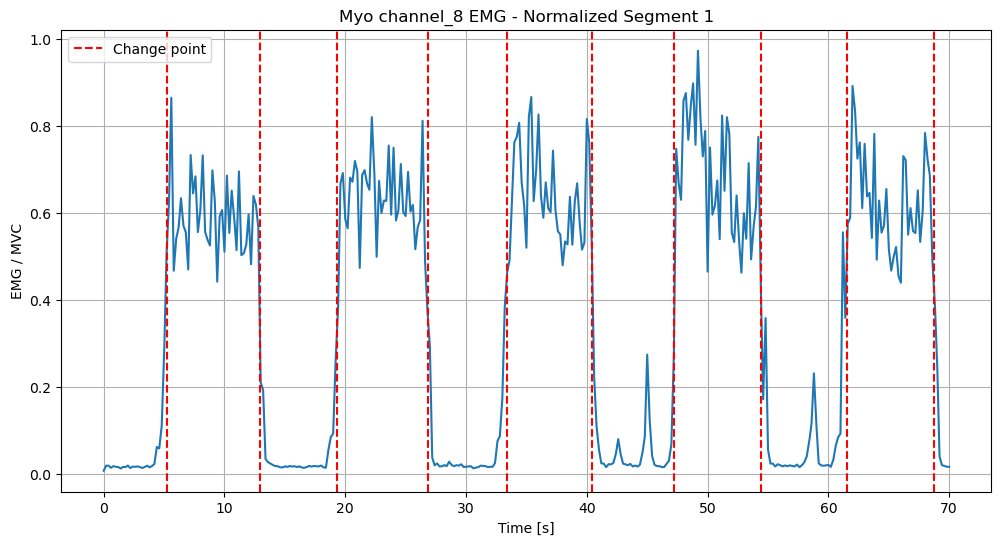

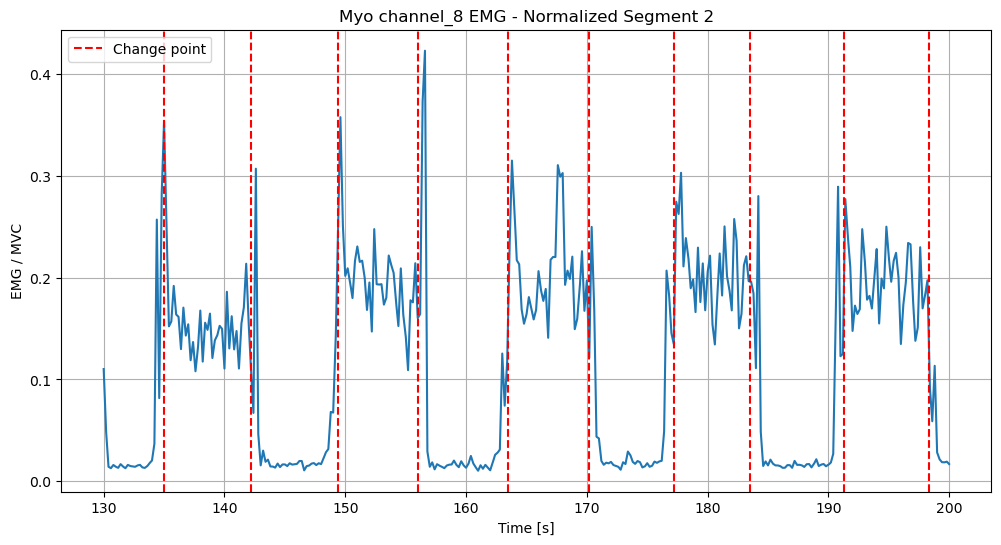

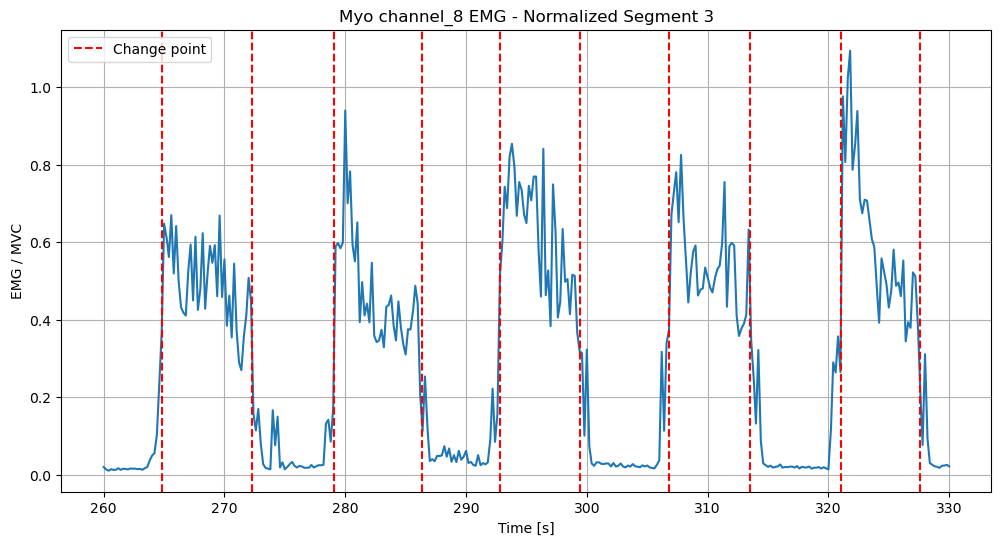

In [205]:
# Plot normalized EMG signals for each Myo channel and segment with breakpoints shown
for channel in channel_names:
    for i in range(len(emg_time_cut_myo[channel])):
        signal = emg_norm_cut_myo[channel][i]
        time = emg_time_cut_myo[channel][i]
        breakpoints_sl = breakpoints_myo[i]  
        plot_emg_signal(signal, time, title=f"Myo {channel} EMG - Normalized Segment {i+1}", xlabel="Time [s]", 
                        ylabel="EMG / MVC", breakpoints=breakpoints_sl)

TRIGNO PLOT

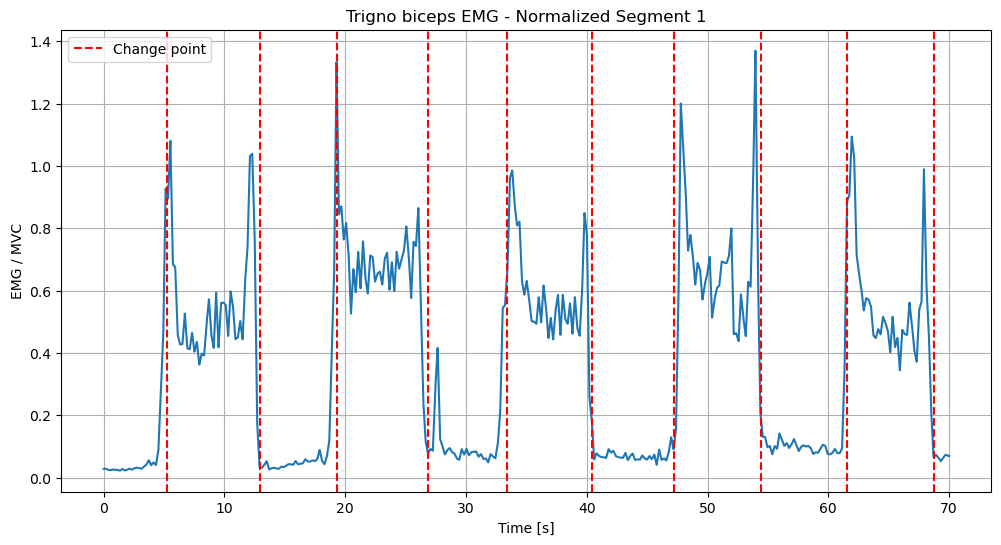

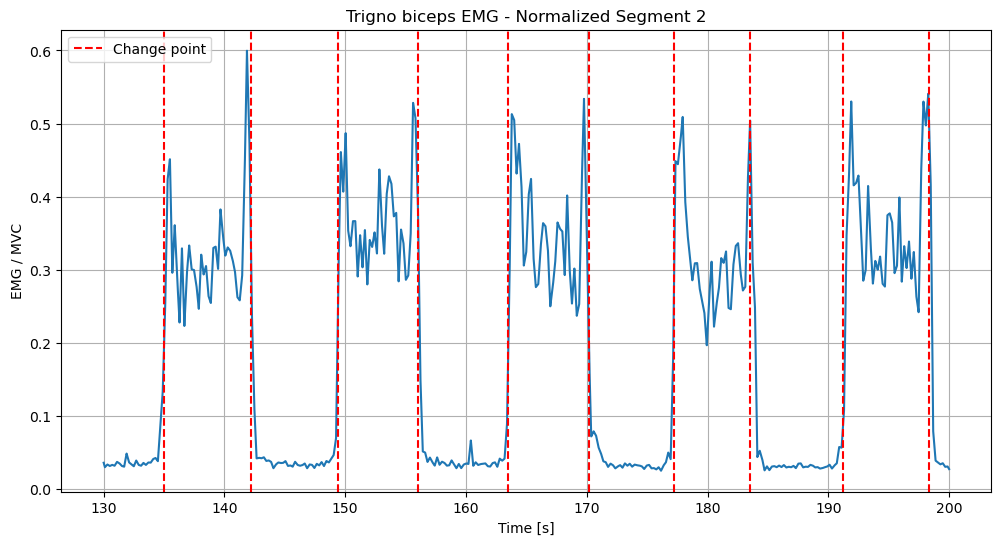

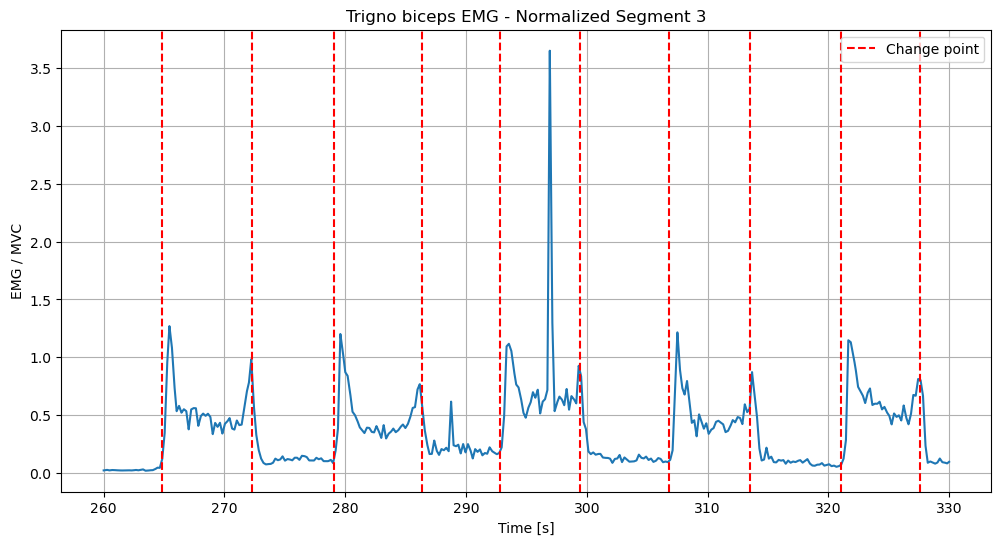

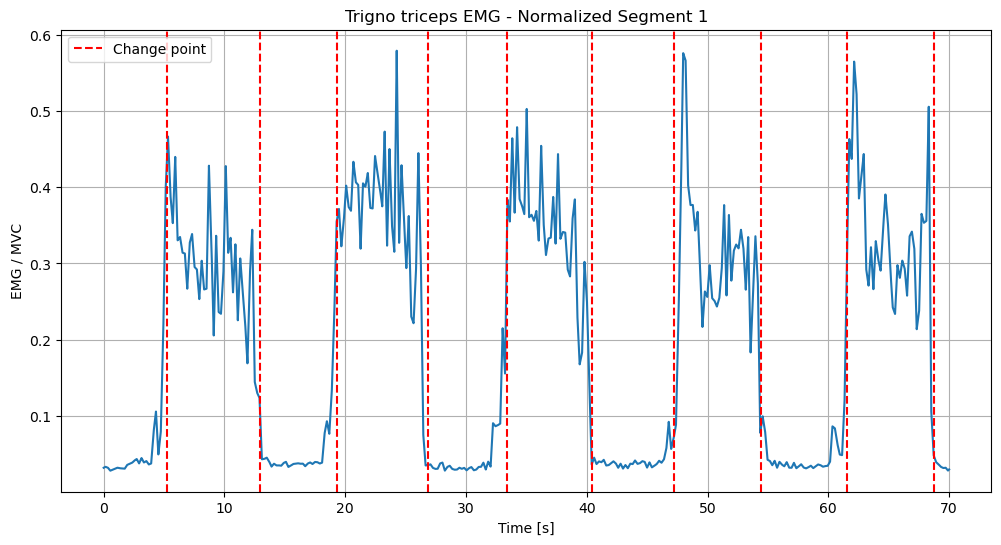

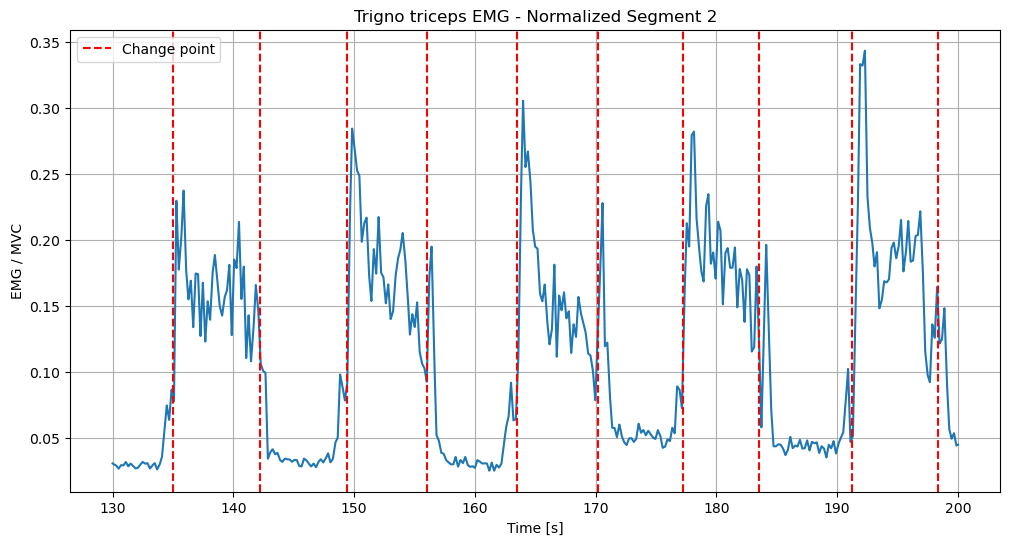

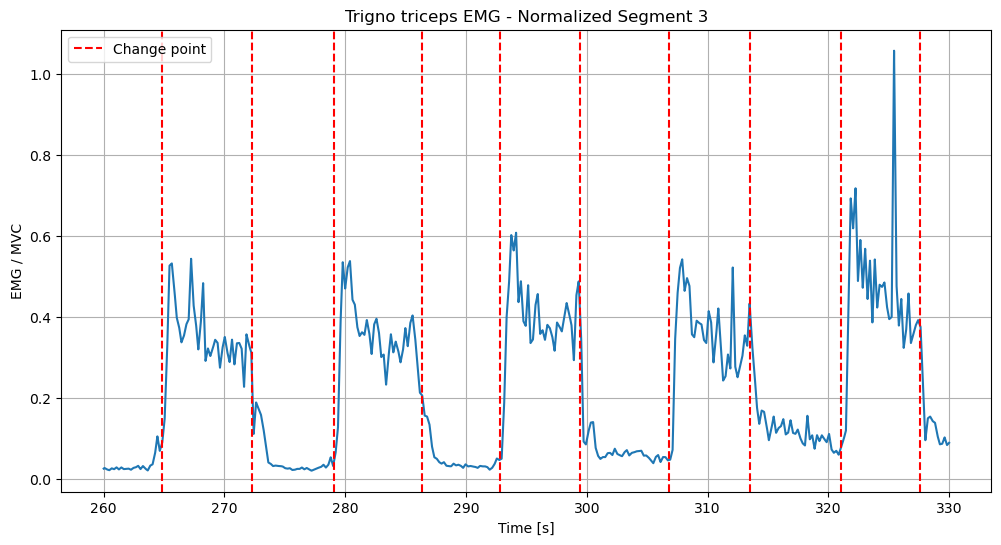

In [206]:
# Plot normalized EMG signals for each Trigno muscle and segment with breakpoints shown
for muscle in muscle_names:
    for i in range(len(emg_time_cut_trigno[muscle])):
        signal = emg_norm_cut_trigno[muscle][i]
        time = emg_time_cut_trigno[muscle][i]
        start_idx = i * n_lifts * 2
        end_idx = start_idx + n_lifts * 2
        breakpoints_sl = breakpoints_trigno[start_idx:end_idx]  
        plot_emg_signal(signal, time, title=f"Trigno {muscle} EMG - Normalized Segment {i+1}", xlabel="Time [s]", 
                        ylabel="EMG / MVC", breakpoints=breakpoints_sl)

PLOT FOR PPT

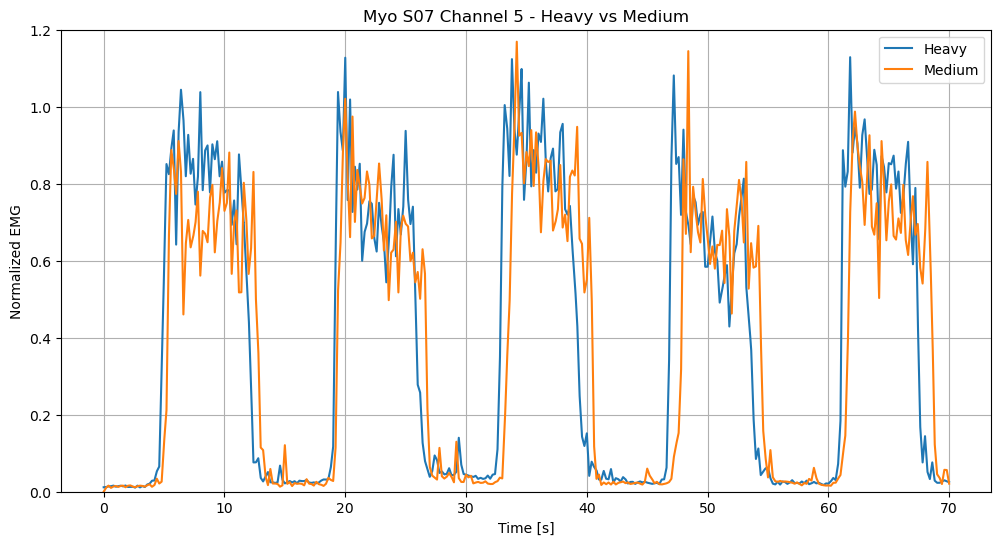

In [207]:
import matplotlib.pyplot as plt
signal1 = emg_norm_cut_myo["channel_5"][0]
time1 = emg_time_cut_myo["channel_5"][0]
signal2 = emg_norm_cut_myo["channel_5"][2]
time2 = emg_time_cut_myo["channel_5"][2] - 260
#breakpoints = breakpoints_myo[1] 

plt.figure(figsize=(12, 6))
plt.plot(time2, signal2, label='Heavy')
plt.plot(time1, signal1, label='Medium')
plt.ylim(0,1.2)

#for i, bp in enumerate(breakpoints):
#    bp_time = time1[bp]
#    plt.axvline(x=bp_time, color='red', linestyle='--', label='Task Switching' if i == 0 else "")
    
plt.title("Myo S07 Channel 5 - Heavy vs Medium")
plt.xlabel("Time [s]")
plt.ylabel("Normalized EMG")
plt.grid(True)
#if breakpoints is not None and len(breakpoints) > 0:
plt.legend()
plt.savefig("S07_HM.png", dpi=300)
plt.show()

# IMU Signal Analysis

MYO

In [70]:
for i in range(len(imu_time_myo)):
    fs_myo = fs_imu_list_myo[i] # Sampling frequency per trial
    windows_idx = [(int(fs_myo * start), int(fs_myo * end)) for start, end in windows_s] # Convert time windows to index ranges
    windows_idx_imu_list_myo.append(windows_idx) # Store window indices list

In [71]:
# Segment raw Myo IMU data and corresponding time arrays based on window indices
imu_myo_raw_cut, imu_myo_times_cut = detect_segments_imu_myo(imu_time_myo, imu_myo, windows_idx_imu_list_myo, fs_imu_list_myo)

In [72]:
#plot_imu_segmented_myo(imu_myo_raw_cut, imu_myo_times_cut, flag=True) # Plot segmented Myo IMU data 

In [73]:
# Process raw segmented Myo IMU data by applying filtering and preprocessing with specified cutoff frequency
imu_processed_myo = process_imu_myo(imu_myo_raw_cut, imu_myo_times_cut, cutoff_imu)

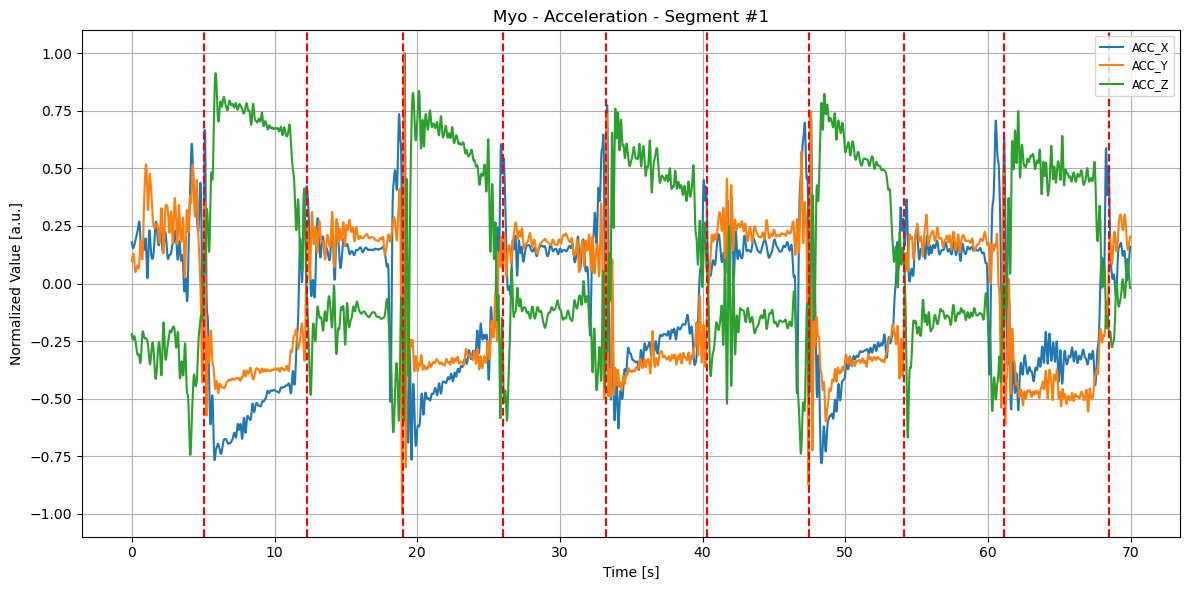

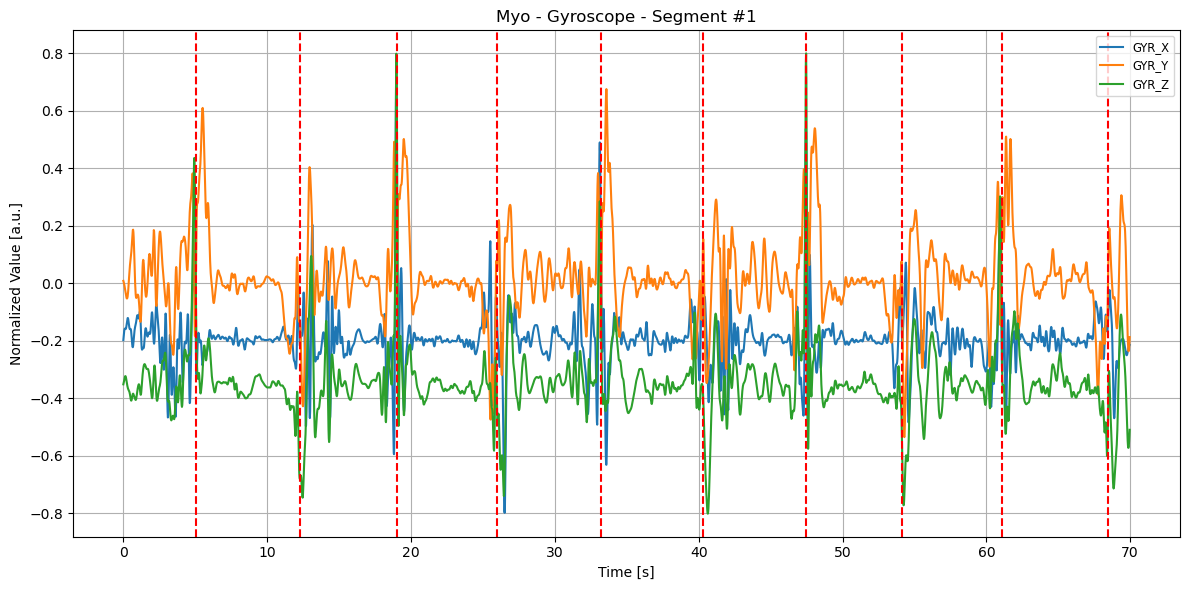

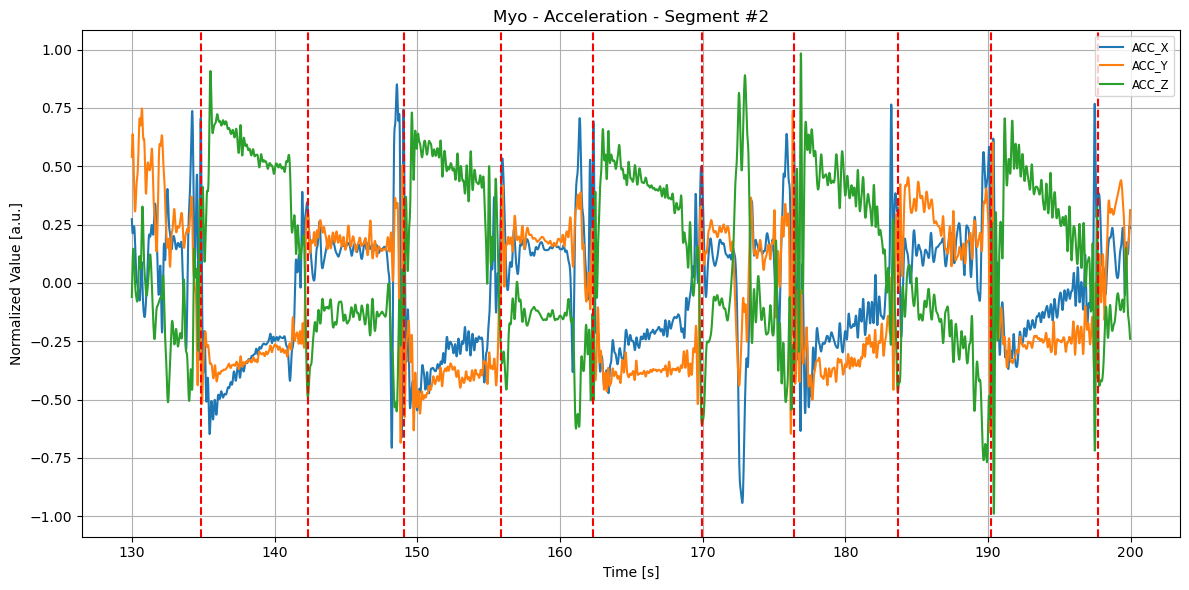

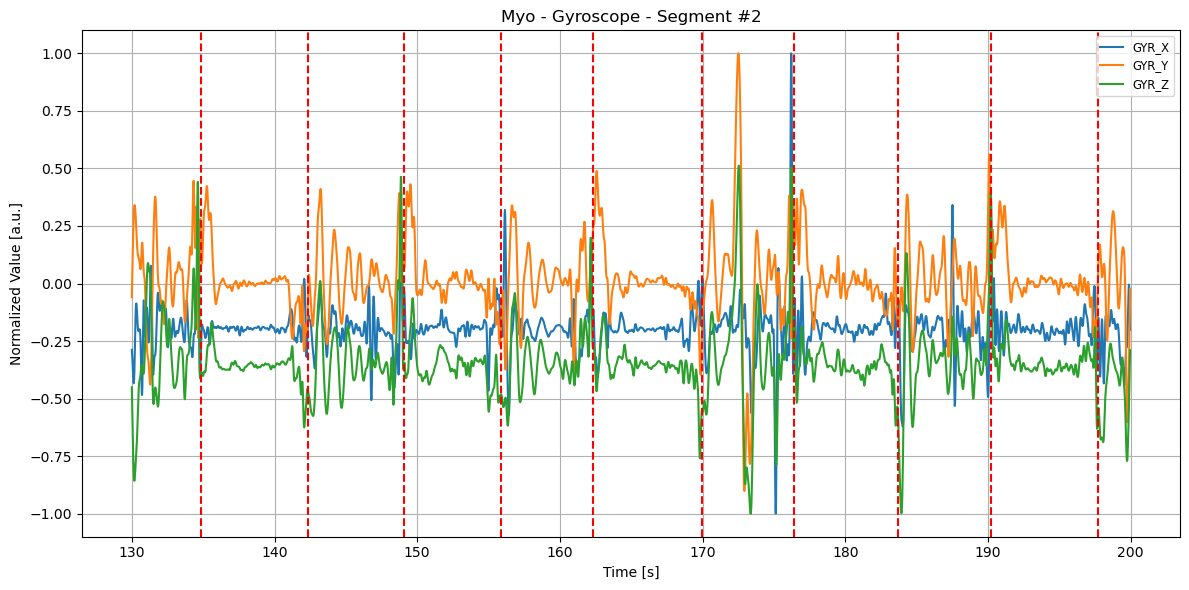

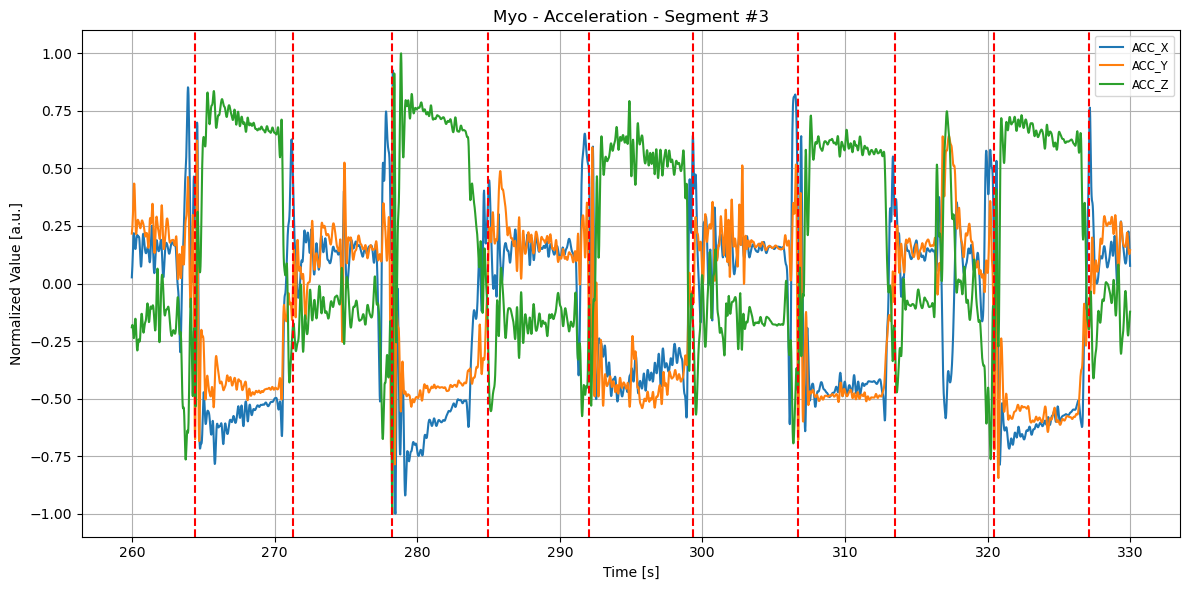

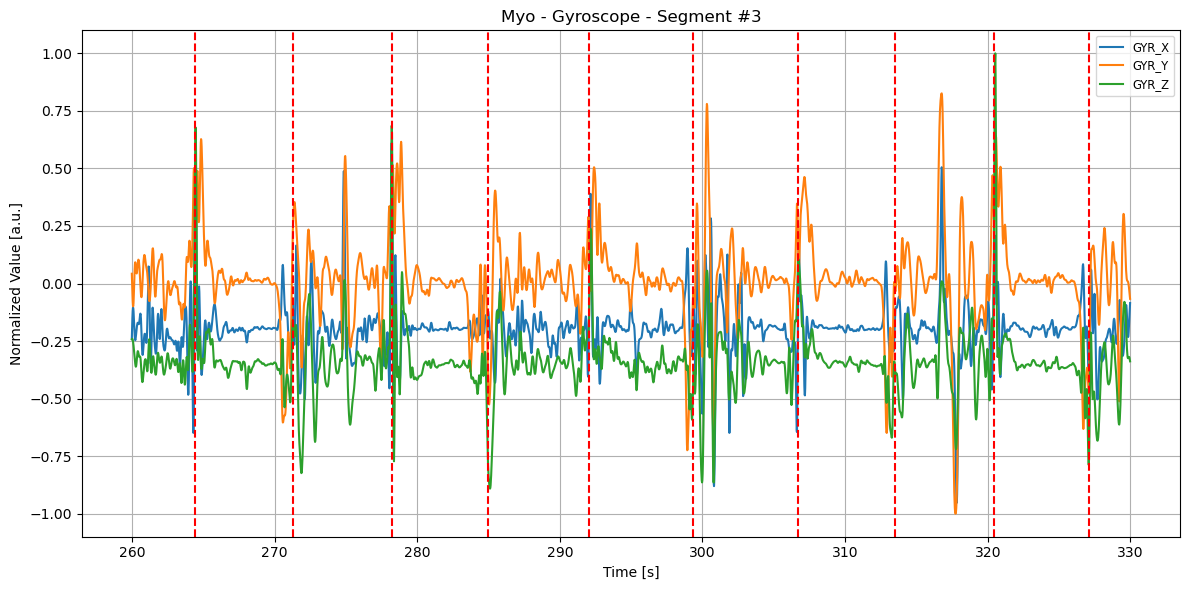

In [74]:
# Adjust breakpoint indices to actual time values considering segment offset, then plot processed Myo IMU data with breakpoints shown
bkps_times = [[idx / fs_emg_list_ext_myo[i] + 130 * i for idx in segment] for i, segment in enumerate(breakpoints_myo)]
plot_imu_segmented_myo(imu_processed_myo, imu_myo_times_cut, flag=False, breakpoints_times=bkps_times)

PLOT FOR PPT

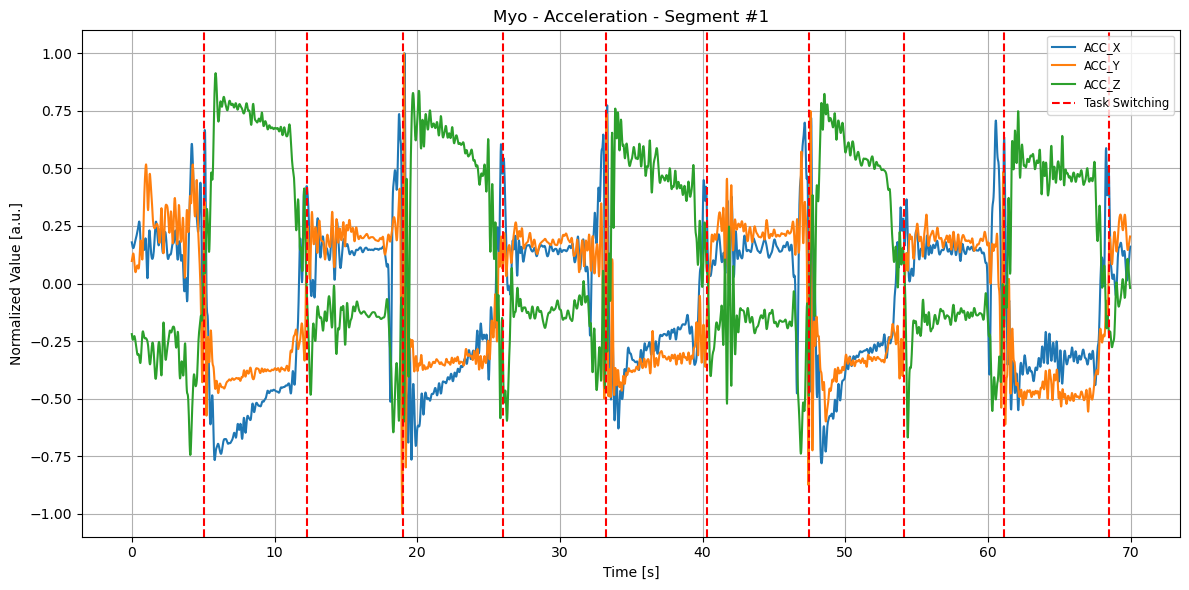

In [80]:
imu_raw_cut = imu_processed_myo
imu_times_cut = imu_myo_times_cut
breakpoints_times=bkps_times
flag=False

ylabel_map = {
        'ACC_X': 'Acceleration [g]',
        'ACC_Y': 'Acceleration [g]',
        'ACC_Z': 'Acceleration [g]',
        'GYR_X': 'Angular Velocity [deg/s]',
        'GYR_Y': 'Angular Velocity [deg/s]',
        'GYR_Z': 'Angular Velocity [deg/s]',
        'roll': 'Orientation [rad]',
        'pitch': 'Orientation [rad]',
        'yaw': 'Orientation [rad]'
    }

groups = {
        'Acceleration': ['ACC_X', 'ACC_Y', 'ACC_Z']
}

first_acc_signal = groups['Acceleration'][0]
n_segments = len(imu_raw_cut[first_acc_signal])
segment_idx = 0

for group_name, signals in groups.items():
    plt.figure(figsize=(12, 6))
    any_data = False
    
    for signal in signals:
        data_segments = imu_raw_cut.get(signal, [])
        time_segments = imu_times_cut.get(signal, [])
        if segment_idx < len(data_segments) and segment_idx < len(time_segments):
            segment = data_segments[segment_idx]
            time_segment = time_segments[segment_idx]

            plt.plot(time_segment, segment, label=signal)
            any_data = True

    if any_data:
    # Add breakpoint lines if available
        if breakpoints_times is not None:
            first = True
            for t in breakpoints_times[segment_idx]:
                plt.axvline(x=t, color='r', linestyle='--', label='Task Switching' if first else "")
                first = False

        plt.title(f'Myo - {group_name} - Segment #{segment_idx + 1}')
        plt.xlabel('Time [s]')
        if flag:
            plt.ylabel(ylabel_map.get(signals[0], 'Signal Value'))
        else:
            plt.ylabel('Normalized Value [a.u.]')  # a.u. = arbitrary units
            plt.legend(loc='upper right', fontsize='small')
            plt.grid(True)
            plt.tight_layout()
            plt.savefig("accelerations.png", dpi=300)
            plt.show()

TRIGNO

In [32]:
for time in imu_time_trigno:
    fs = 1.0 / np.mean(np.diff(time)) # Estimate sampling frequency from time intervals
    windows_idx = [(int(fs * start), int(fs * end)) for start, end in windows_s] # Convert time windows to index ranges
    windows_idx_imu_list_trigno.append(windows_idx) # Store window indices list
    fs_imu_list_trigno.append(fs)  # Store estimated sampling frequency

In [33]:
# Segment raw Trigno IMU data and corresponding time arrays based on window indices
imu_raw_cut_trigno, imu_time_cut_trigno = detect_segments_imu(imu_time_trigno, muscle_imu_trigno, muscle_names, axes,
                                                              windows_idx_imu_list_trigno, fs_imu_list_trigno)

In [34]:
# Plot segmented Trigno IMU data 
#for i in range (len(imu_time_cut_trigno[muscle_names[0]]['ACC_X'])):
#    muscle_imu_i = {}
#    imu_time_i = {}
#    for muscle in muscle_imu_trigno:
#        muscle_imu_i[muscle] = {}
#        imu_time_i[muscle] = {}
#        for channel in muscle_imu_trigno[muscle]:
#            muscle_imu_i[muscle][channel] = imu_raw_cut_trigno[muscle][channel][i]
#            imu_time_i[muscle][channel] = imu_time_cut_trigno[muscle][channel][i]           
#    plot_imu_signals(muscle_imu_i, imu_time_i, muscle_names, axes, file_label=f"Segment #{i+1}")

In [35]:
# Process raw segmented Trigno IMU data by applying filtering and preprocessing with specified cutoff frequency
muscle_imu_processed_trigno = process_imu_segments(imu_raw_cut_trigno, imu_time_cut_trigno, muscle_names, axes, cutoff_imu)

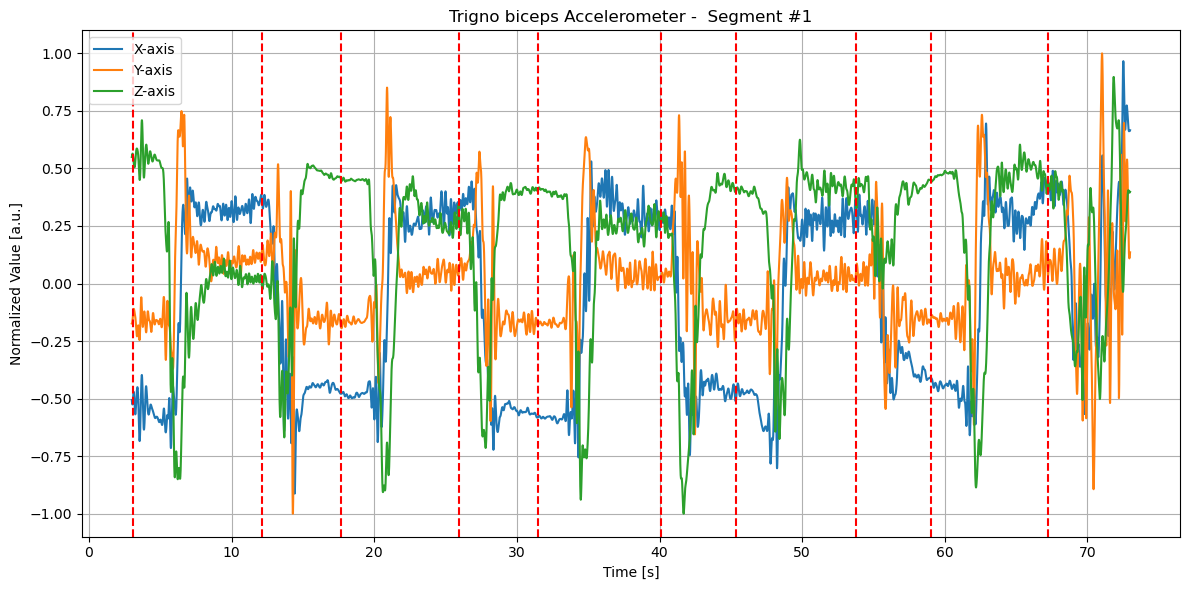

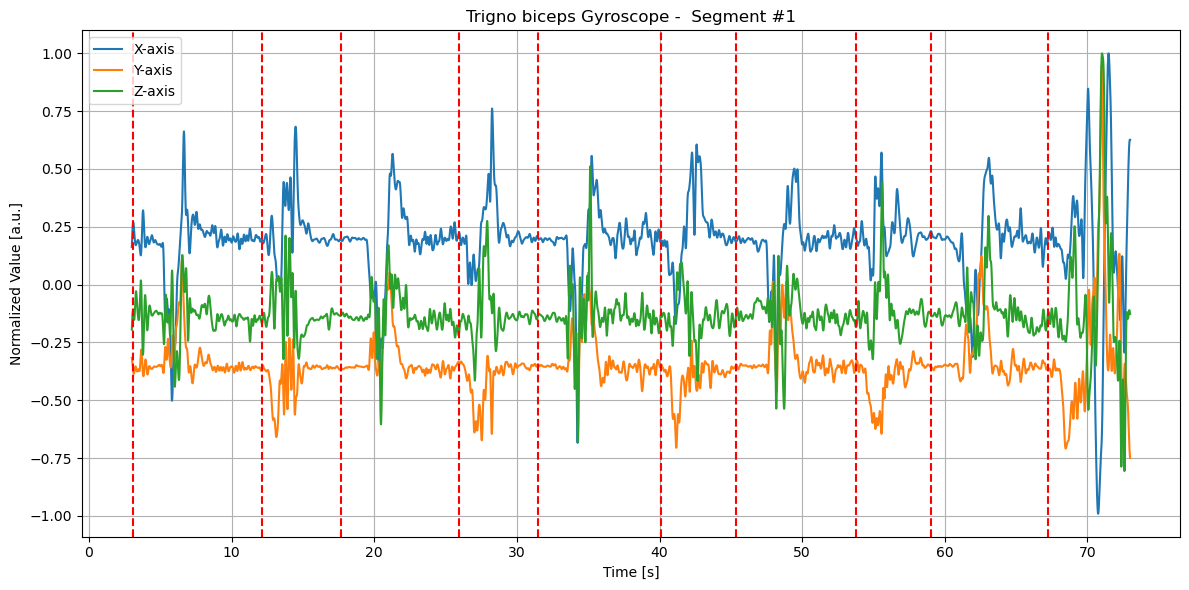

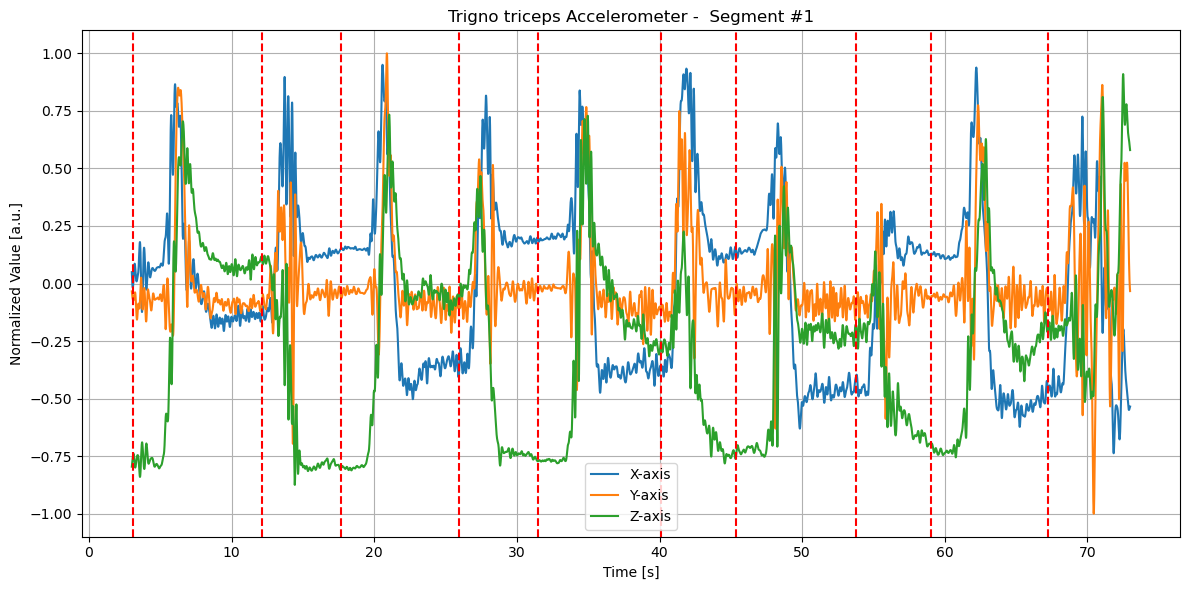

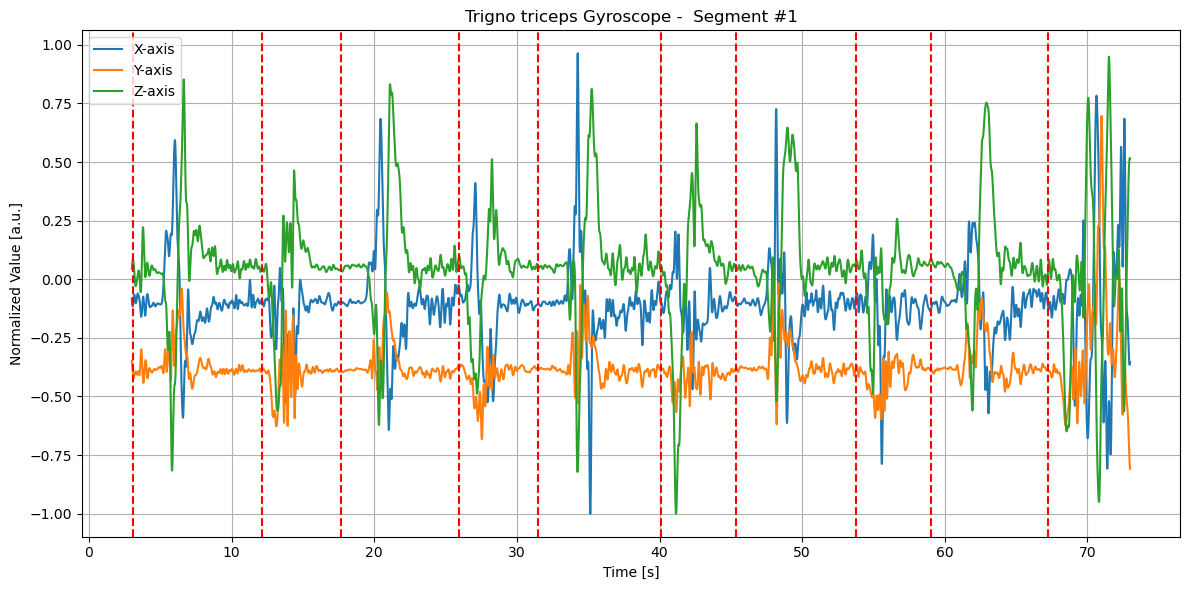

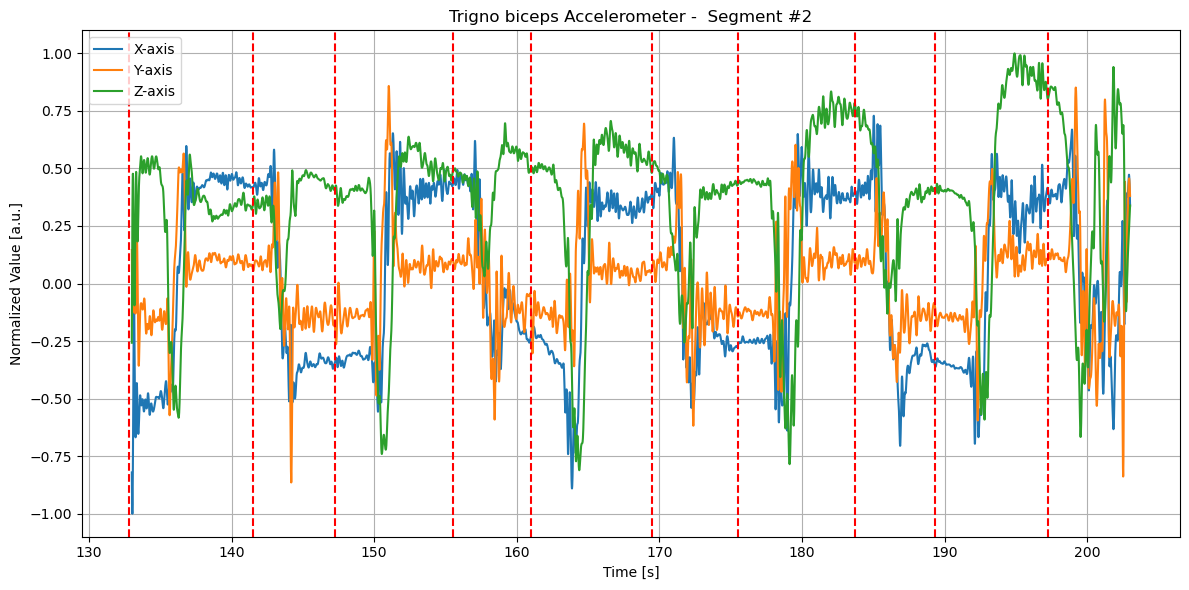

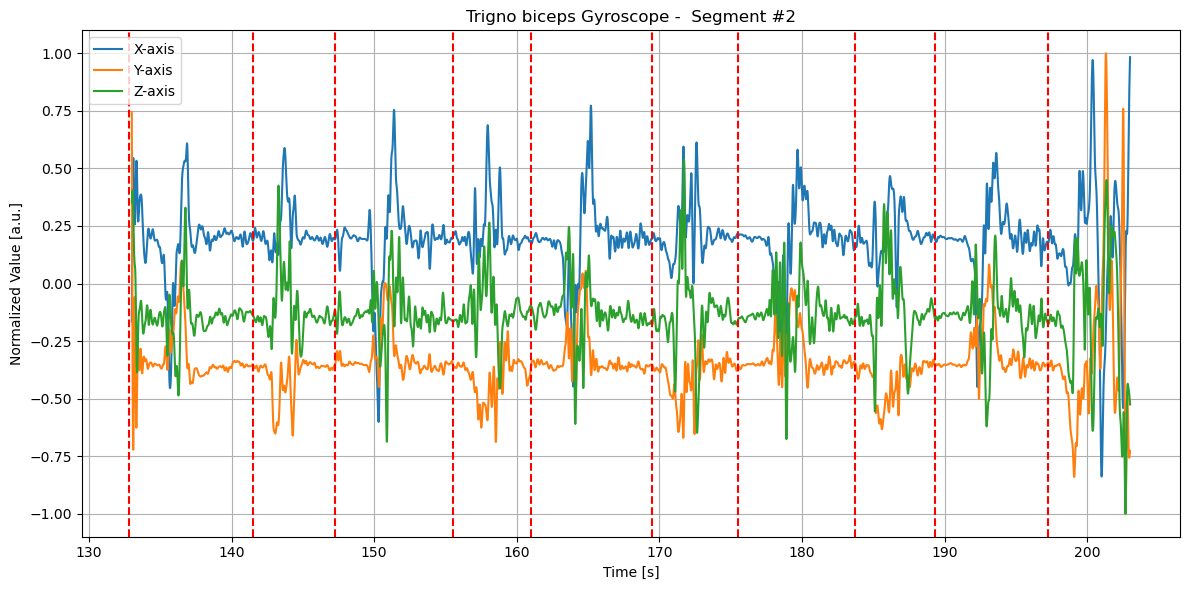

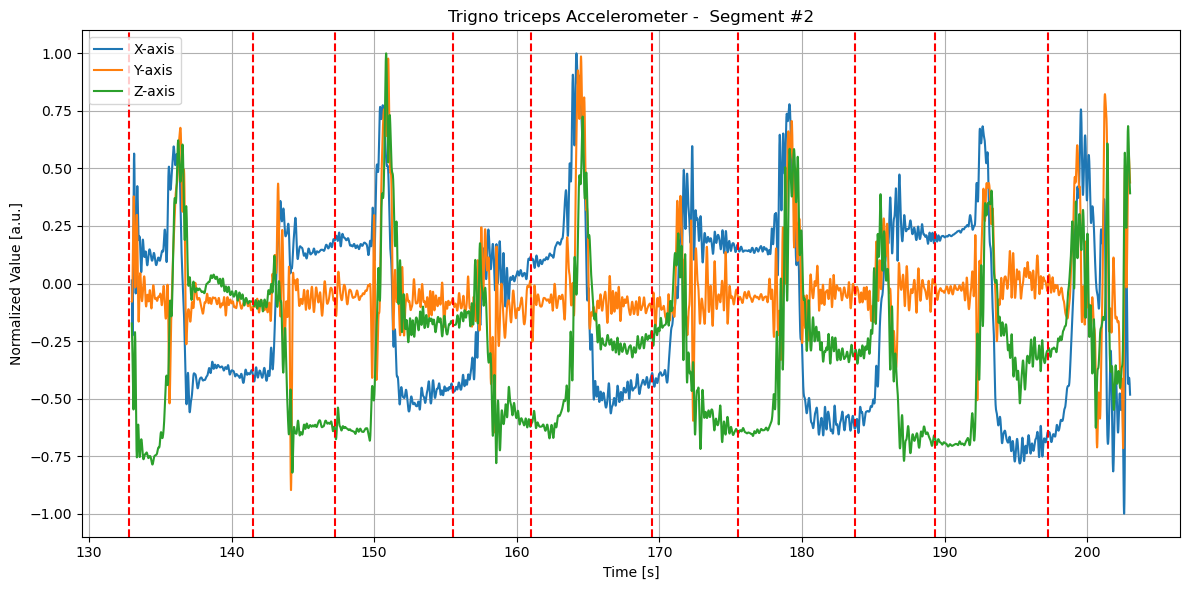

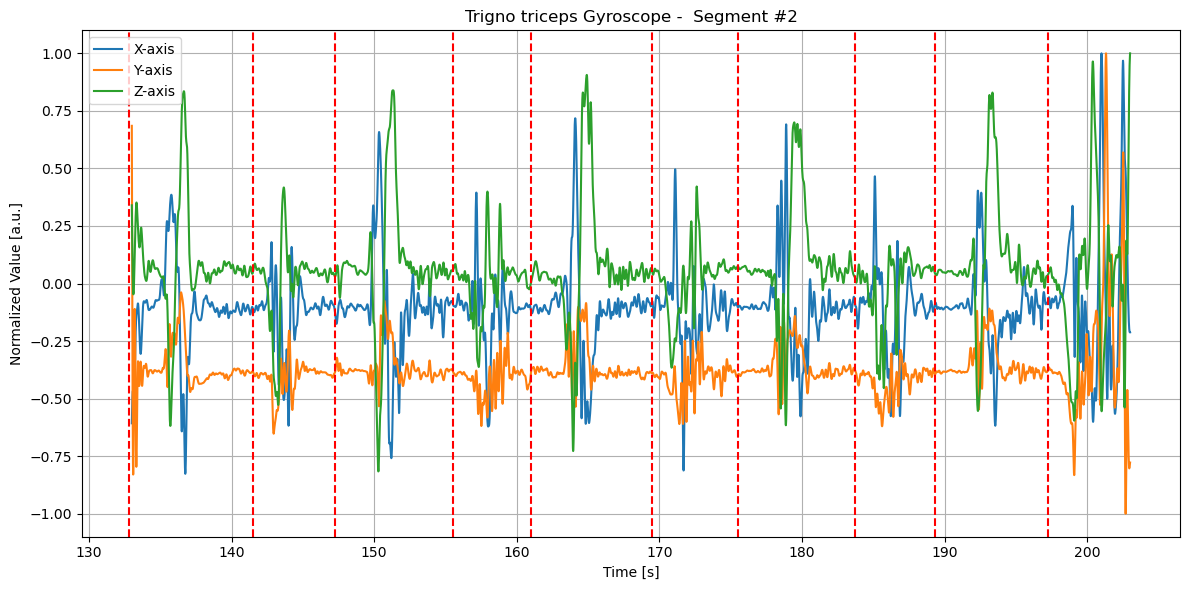

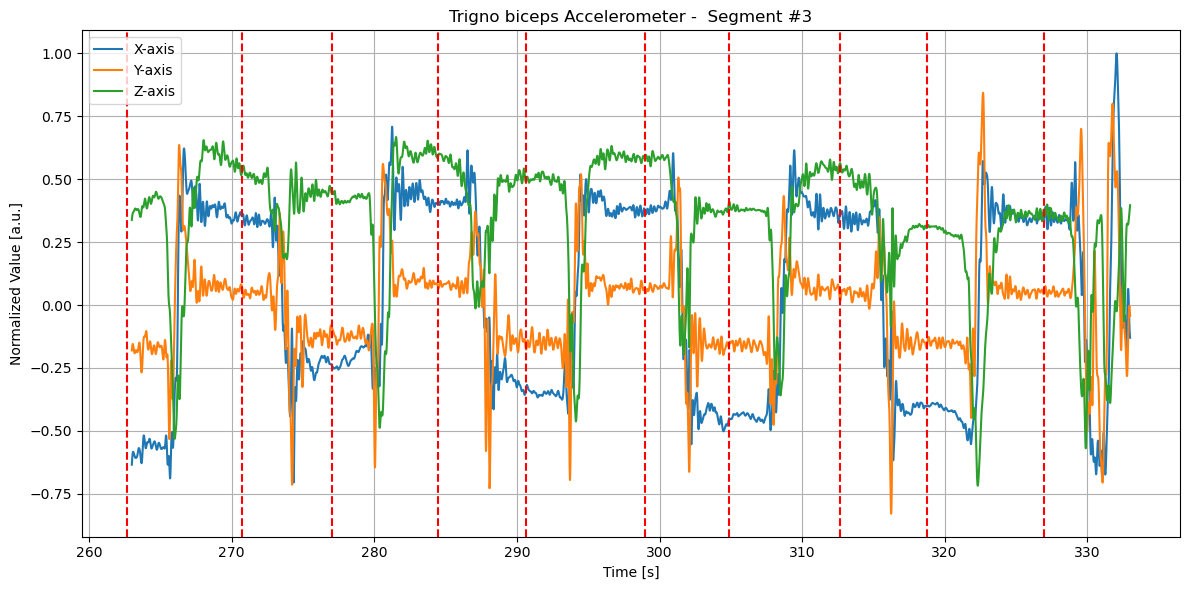

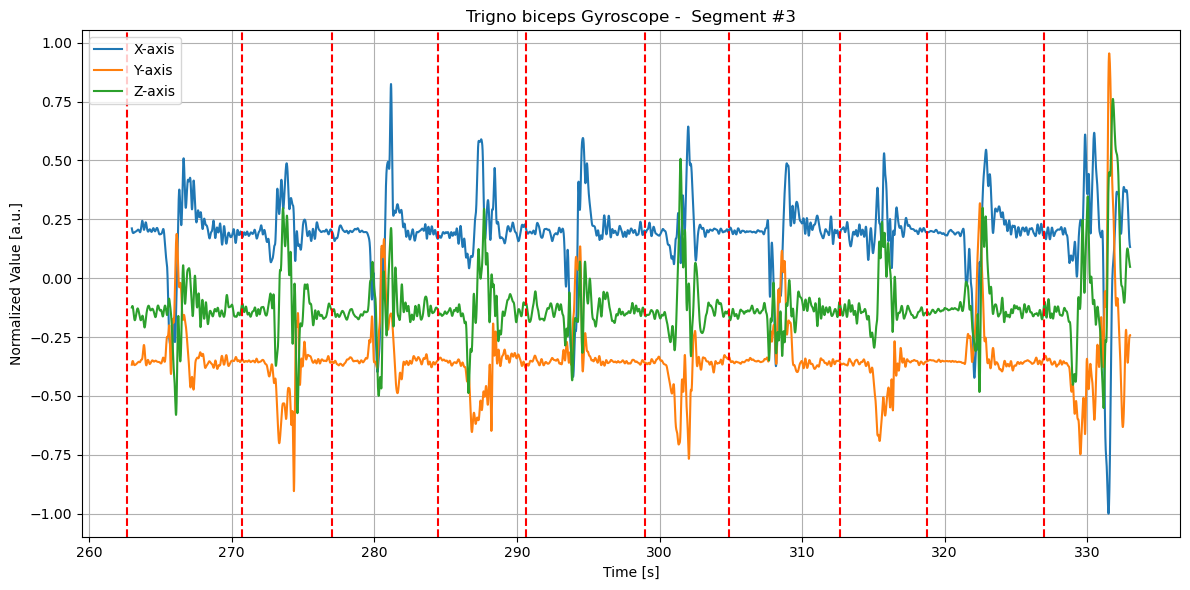

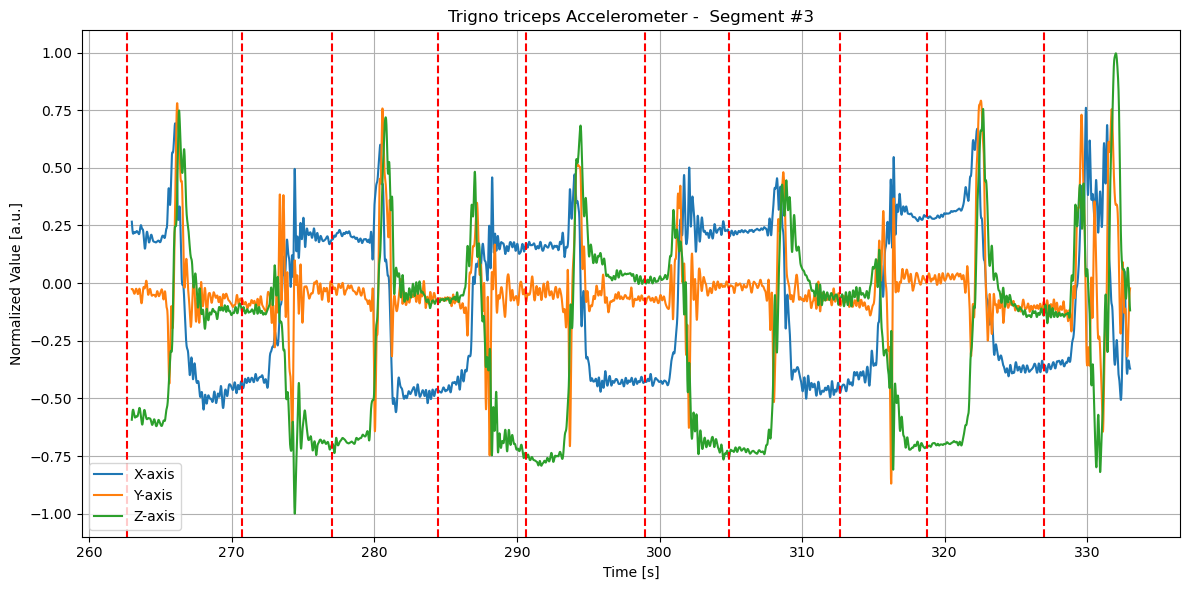

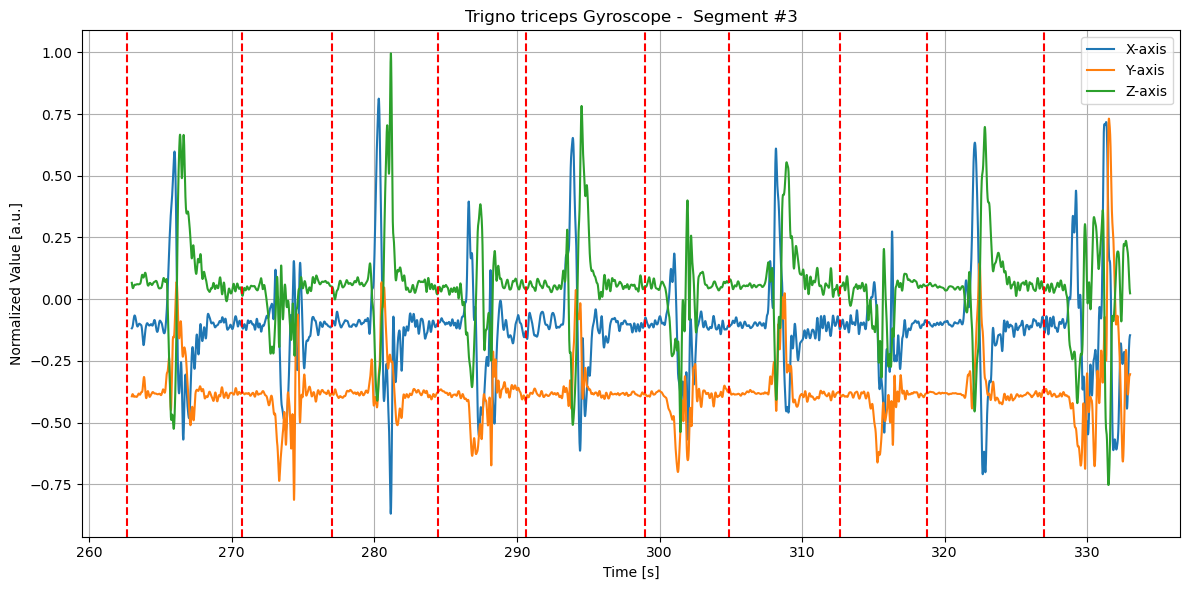

In [36]:
# Adjust breakpoint indices to actual time values considering segment offset, then plot processed Trigno IMU data with breakpoints shown
for i in range(len(imu_time_cut_trigno[muscle_names[0]]['ACC_X'])):
    muscle_imu_i = {}
    imu_time_i = {}
    
    for muscle in muscle_imu_trigno:
        muscle_imu_i[muscle] = {}
        imu_time_i[muscle] = {}
        
        for channel in muscle_imu_trigno[muscle]:
            muscle_imu_i[muscle][channel] = muscle_imu_processed_trigno[muscle][channel][i]
            imu_time_i[muscle][channel] = imu_time_cut_trigno[muscle][channel][i]

    current_bkps = breakpoints_myo[i]
    fs = fs_emg_list_ext_myo[i]
    bkps_times = [idx / fs + 130 * i for idx in current_bkps]
    y_l = {'acc': 'Normalized Value [a.u.]',
            'gyr': 'Normalized Value [a.u.]'}
    
    plot_imu_signals(muscle_imu_i, imu_time_i, muscle_names, axes, y_labels=y_l, file_label=f"Segment #{i+1}", breakpoints_times=bkps_times)

# Windowing & Feature Extraction

MYO

In [37]:
# Windowing of processed Myo EMG data
normalized_win_myo, filtered_win_myo, time_win_myo = extract_emg_windows_v2(emg_norm_cut_myo, emg_filt_cut_myo, emg_time_cut_myo, w_d, ov)

In [38]:
# Windowing of processed Myo IMU data
segmented_imu_myo, segmented_times_myo = extract_imu_windows_myo(imu_processed_myo, imu_myo_times_cut, w_d, ov)

In [39]:
# Features Extraction
time_features_norm_myo = extract_emg_features(normalized_win_myo, features_list_norm)
time_features_filt_myo = extract_emg_features(filtered_win_myo, features_list_filt)  
freq_features_norm_myo = extract_emg_features(normalized_win_myo, features_list_freq) 
features_imu_myo = extract_imu_features_myo(segmented_imu_myo, features_list_imu)
vm_features_myo = compute_vm_features_myo(segmented_imu_myo) # Compute vector magnitude features from Myo IMU data  

TRIGNO

In [40]:
# Windowing of processed Trigno EMG data
normalized_win_trigno, filtered_win_trigno, time_win_trigno = extract_emg_windows_v2(emg_norm_cut_trigno, emg_filt_cut_trigno, emg_time_cut_trigno,
                                                                                     w_d, ov)

In [41]:
# Windowing of processed Trigno IMU data 
segmented_imu_trigno, segmented_times_trigno = extract_imu_windows(muscle_imu_processed_trigno, imu_time_cut_trigno, w_d, ov)

In [42]:
# Features Extraction
time_features_norm_trigno = extract_emg_features(normalized_win_trigno, features_list_norm)
time_features_filt_trigno = extract_emg_features(filtered_win_trigno, features_list_filt)  
freq_features_norm_trigno = extract_emg_features(normalized_win_trigno, features_list_freq)    
features_imu_trigno = extract_imu_features(segmented_imu_trigno, features_list_imu) 
vm_features_trigno = compute_vm_features(segmented_imu_trigno)  # Compute vector magnitude features from Trigno IMU data  

In [43]:
# Rename EMG feature columns for Trigno data by prefixing 'emg_' with 'emg_trigno_' to distinguish from Myo features
for lst in [time_features_norm_trigno, freq_features_norm_trigno, time_features_filt_trigno]:
    for i, df in enumerate(lst):
        lst[i].columns = [c.replace('emg_', 'emg_trigno_') for c in df.columns]

COMBINED DATASET

In [44]:
# Combine various extracted feature lists from Myo and Trigno devices into a single DataFrame
dfs = combine_multiple_features_lists(time_features_norm_myo, time_features_filt_myo, freq_features_norm_myo, 
                                      features_imu_myo, vm_features_myo,
                                      time_features_norm_trigno, time_features_filt_trigno, freq_features_norm_trigno, 
                                      features_imu_trigno, vm_features_trigno) 

## Label Assignment

In [45]:
# Assign true labels to data windows
dfs['label'] = assign_emg_labels_v2(breakpoints_myo, windows_per_segment, fs_emg_list_ext_myo, w_d, ov, intensity_level, n_lifts)

# Features Export

In [46]:
output_path = os.path.join(output_folder, output_filename)  # Create full path for output CSV file
dfs.to_csv(output_path, index=False)  # Save dataframe with features and labels to CSV